In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt

In [4]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [7]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [6]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Get timeseries of median/average reanalysis snow depth for 3 years:

In [8]:
#swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'lat': 'y', 'lon': 'x'})
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)
swe_sca_ds_sierras = swe_sca_ds.rio.clip(sierras.geometry)

In [9]:
swe_sca_ds_sierras = swe_sca_ds_sierras.rename({'y': 'lat', 'x': 'lon'})

In [10]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs_sierras.rename({'y': 'lat', 'x': 'lon'})

In [11]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_sierras.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) ))

In [12]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [13]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [14]:
# 4. Apply mask
swe_sca_ds_roi = swe_sca_ds_sierras.where(mask)

In [15]:
# 4. Apply mask
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_sierras.where(mask)

In [16]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs_sierras.rename({'lat': 'y', 'lon': 'x'})
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_roi.rename({'lat': 'y', 'lon': 'x'})
mask = mask.rename({'lat': 'y', 'lon': 'x'})

### Calculate areal fsca for sierras:

In [58]:
import numpy as np

# Grid spacing in degrees
dx = abs(float(swe_sca_ds_allyrs_sierras.x[1] - swe_sca_ds_allyrs_sierras.x[0]))
dy = abs(float(swe_sca_ds_allyrs_sierras.y[1] - swe_sca_ds_allyrs_sierras.y[0]))

# Calculate cell area accounting for latitude (in m²)
R = 6371000  # Earth radius in meters
lat = swe_sca_ds_allyrs_sierras.y  # latitude values

# Cell area varies with latitude: width shrinks toward poles
cell_area = (R ** 2) * np.cos(np.deg2rad(lat)) * np.deg2rad(dx) * np.deg2rad(dy)

# Create a 2D cell area grid and mask for valid (non-NaN) cells
# Use a single timestep to determine valid cells in the Sierra region
sca_sample = swe_sca_ds_allyrs_sierras.SCA_Post.isel(time=0)
valid_mask = ~np.isnan(sca_sample)

# Calculate total area by broadcasting cell_area to 2D and summing where valid
total_area_fixed = (cell_area * valid_mask).sum().values  # in m²

print(f"Total area of Sierra region: {total_area_fixed / 1e6:.2f} km²")

Total area of Sierra region: 61670.96 km²


In [59]:
# Need to count actual valid cells per timestep for proper weighting

valid_cells = ~np.isnan(swe_sca_ds_allyrs_sierras.SCA_Post)
total_area_per_time = (cell_area * valid_cells).sum(dim=('y', 'x'))

print(f"Min: {total_area_per_time.min().values:.2f}, Max: {total_area_per_time.max().values:.2f}")

Min: 61670955607.22, Max: 61670955607.22


In [60]:
# Calculate area-weighted mean SCA for each day
# Sum(SCA * cell_area) / total_area
mean_sca_area_weighted = ((swe_sca_ds_allyrs_sierras.SCA_Post * cell_area).sum(dim=('y', 'x'), skipna=True) / total_area_fixed).compute()

In [141]:
mean_sca_area_weighted

<xarray.DataArray (time: 13514)> Size: 108kB
array([9.28828377e-03, 5.70783709e-02, 3.60025719e-02, ...,
       1.67654175e-02, 1.11825256e-02, 5.72164694e-05], shape=(13514,))
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

Text(0.5, 1.0, 'Area-Weighted Mean SCA in Sierra Region (2018-2021)')

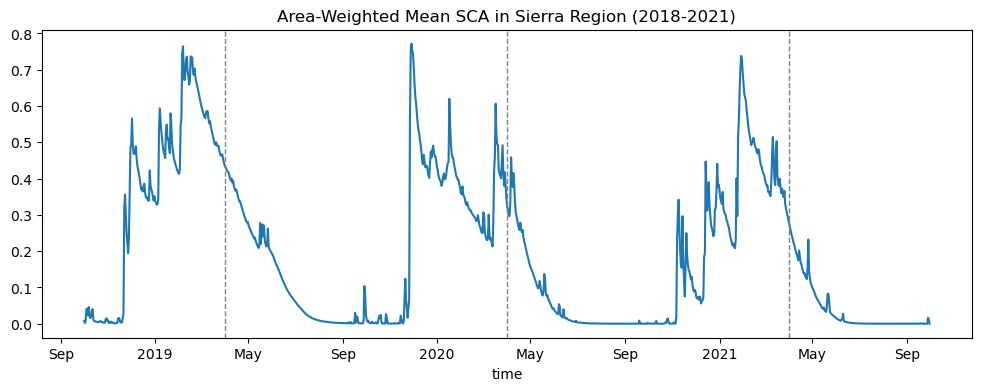

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
mean_sca_area_weighted.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax)

# Add dashed vertical lines at April 1 of each year
for year in [2019, 2020, 2021]:
    ax.axvline(pd.Timestamp(f'{year}-04-01'), color='gray', linestyle='--', linewidth=1)
ax.set_title('Area-Weighted Mean SCA in Sierra Region (2018-2021)')

### Calculate the running 7 day median and the integral for December 1 - April 1:

In [143]:
# Calculate centered 7-day running median of area-weighted FSCA
mean_sca_area_weighted_7day_median = mean_sca_area_weighted.rolling(time=7, center=True).median()

# Calculate integral of smoothed FSCA from Dec 1 - April 1 for each water year
from scipy import integrate
import pandas as pd

# Get unique water years (water year starts Oct 1, so Dec belongs to the same WY as the following April)
water_years = mean_sca_area_weighted['time'].dt.year.values
water_years_unique = sorted(set(water_years))

integrals = []
wy_list = []

for wy in water_years_unique:
    # Dec 1 of previous calendar year to April 1 of current calendar year
    start_date = f'{wy-1}-12-01'
    end_date = f'{wy}-04-01'
    
    # Select the time period from the smoothed data
    subset = mean_sca_area_weighted_7day_median.sel(time=slice(start_date, end_date))
    
    # Drop NaN values from rolling median edges
    subset = subset.dropna(dim='time')
    
    if len(subset) > 1:
        # Convert time to numeric (days since start)
        time_numeric = (subset['time'] - subset['time'][0]).dt.days.values.astype(float)
        
        # Calculate integral using trapezoidal rule
        integral = integrate.trapezoid(subset.values, time_numeric)
        
        integrals.append(integral)
        wy_list.append(wy)

# Create DataFrame with water year as index
sierras_fsca_integral_df = pd.DataFrame({
    'sierras_fsca_integral': integrals
}, index=pd.Index(wy_list, name='water_year'))

sierras_fsca_integral_df

,sierras_fsca_integral
water_year,
1985,60.412529
1986,52.817956
1987,39.383893
1988,56.446056
1989,62.812649
1990,45.898409
1991,43.507434
1992,55.318641
1993,69.485911


Text(0.5, 1.0, 'Rolling Median Area-Weighted Mean SCA in Sierra Region (2018-2021)')

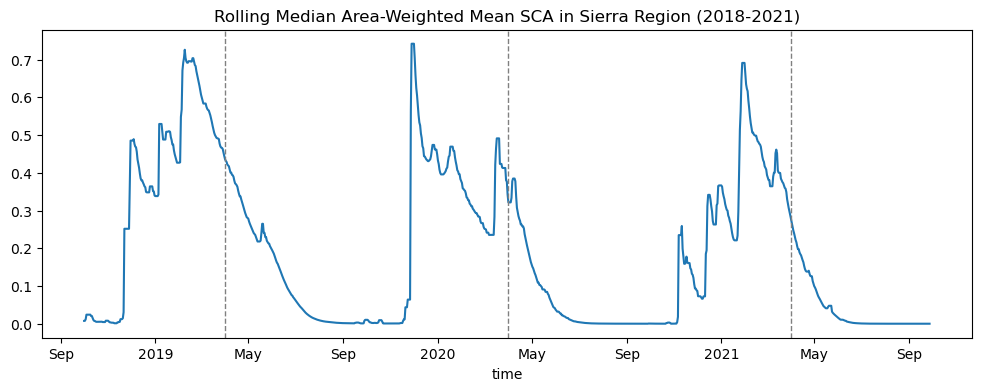

In [144]:
fig, ax = plt.subplots(figsize=(12, 4))
mean_sca_area_weighted_7day_median.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax)

# Add dashed vertical lines at April 1 of each year
for year in [2019, 2020, 2021]:
    ax.axvline(pd.Timestamp(f'{year}-04-01'), color='gray', linestyle='--', linewidth=1)
ax.set_title('Rolling Median Area-Weighted Mean SCA in Sierra Region (2018-2021)')

In [147]:
# Get April 1 mean SWE from swe_sca_ds_allyrs_roi for each year
april1_swe = swe_sca_ds_allyrs_roi.SWE_Post.sel(
    time=((swe_sca_ds_allyrs_roi['time'].dt.month == 4) & (swe_sca_ds_allyrs_roi['time'].dt.day == 1))
).mean(dim=['x', 'y']).compute()

# Create DataFrame of April 1 mean SWE with year as index
april1_years = april1_swe['time'].dt.year.values
april1_swe_df = pd.DataFrame({
    'april1_mean_swe': april1_swe.values
}, index=pd.Index(april1_years, name='water_year'))

KeyboardInterrupt: 

### Plot 1 April mean SWE versus the integral of fSCA:

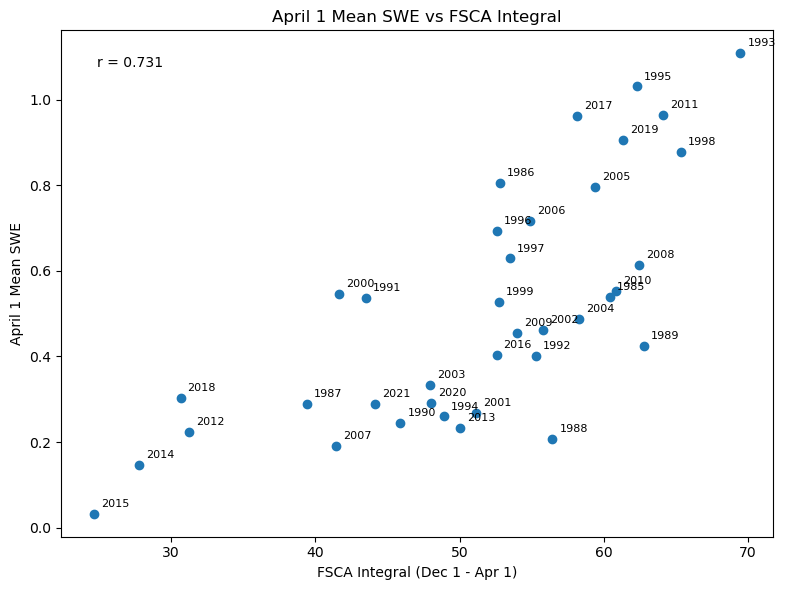

In [ ]:
# Merge with FSCA integral dataframe
combined_df = sierras_fsca_integral_df.join(april1_swe_df, how='inner')

# Plot April 1 mean SWE vs FSCA integral
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(combined_df['sierras_fsca_integral'], combined_df['april1_mean_swe'])

# Add year labels to points
for year in combined_df.index:
    ax.annotate(str(year), 
                (combined_df.loc[year, 'sierras_fsca_integral'], 
                 combined_df.loc[year, 'april1_mean_swe']),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('FSCA Integral (Dec 1 - Apr 1)')
ax.set_ylabel('April 1 Mean SWE')
ax.set_title('April 1 Mean SWE vs FSCA Integral')

# Calculate and display correlation
corr = combined_df['sierras_fsca_integral'].corr(combined_df['april1_mean_swe'])
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()

### Calculate the line of best fit to the above data, and calculate the residuals:

In [148]:
# Fit line of best fit and calculate residuals
from scipy import stats

x_data = combined_df['sierras_fsca_integral'].values
y_data = combined_df['april1_mean_swe'].values

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)

# Predicted values from best fit line
y_predicted = slope * x_data + intercept

# Calculate residuals
residuals = y_data - y_predicted

# Add to dataframe
combined_df['predicted_swe'] = y_predicted
combined_df['residuals'] = residuals

print(f"Line of best fit: y = {slope:.6f}x + {intercept:.4f}")
print(f"R² = {r_value**2:.4f}, p-value = {p_value:.4e}")
print(f"\nResiduals:")
combined_df[['april1_mean_swe', 'predicted_swe', 'residuals']]

Line of best fit: y = 0.018755x + -0.4574
R² = 0.5341, p-value = 2.8028e-07

Residuals:


,april1_mean_swe,predicted_swe,residuals
water_year,,,
1985,0.538987,0.675622,-0.136635
1986,0.804167,0.533187,0.270980
1987,0.289938,0.281233,0.008705
1988,0.207489,0.601231,-0.393743
1989,0.425504,0.720635,-0.295131
1990,0.243471,0.403412,-0.159941
1991,0.535809,0.358570,0.177239
1992,0.399962,0.580087,-0.180124
1993,1.108077,0.845791,0.262286


## Run the svd analysis to get pc2 weights:

### Get just April 1 of each year from the timeseries:

In [23]:
# 1. Select April 1 of each year
sd_allyrs_april1 = swe_sca_ds_allyrs_sierras.SD_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) )).compute()

In [24]:
sd_allyrs_april1_snowy = sd_allyrs_april1.where(sd_allyrs_april1.mean(dim='time') > 0.1)

In [25]:
sd_allyrs_april1_snowy_anomalies = (sd_allyrs_april1_snowy - sd_allyrs_april1_snowy.mean(dim='time')) / sd_allyrs_april1_snowy.std(dim='time')

### Stack the space dimension and remove nan values:

In [26]:
# Stack spatial dimensions into a single 'space' dimension
sd_2d_anom = sd_allyrs_april1_snowy_anomalies.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
sd_2d_clean_anom = sd_2d_anom.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
sd_2d_array_anom = sd_2d_clean_anom.values

### Run the SVD on the standardized anomalies:

In [27]:
from scipy.linalg import svd
U_anom_sd, S_anom_sd, V_anom_sd = svd(sd_2d_array_anom.T, full_matrices=False)

### Format the spatial matrix with coordinates:

In [33]:
U_spatial_anom_sd = xr.full_like(sd_2d_clean_anom, np.nan)
U_spatial_anom_sd.values = U_anom_sd.T
U_spatial_unstacked_anom_sd = U_spatial_anom_sd.unstack('space')
U_spatial_unstacked_sorted_anom_sd = U_spatial_unstacked_anom_sd.sortby(['y', 'x'])

### Replace the time coordinate with EOF number:

In [34]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_anom_sd.sizes['time']
U_spatial_eof_anom_sd = U_spatial_unstacked_sorted_anom_sd.copy()
U_spatial_eof_anom_sd = U_spatial_eof_anom_sd.rename({'time': 'EOF'})
U_spatial_eof_anom_sd = U_spatial_eof_anom_sd.assign_coords(EOF=np.arange(1, n_eof+1))

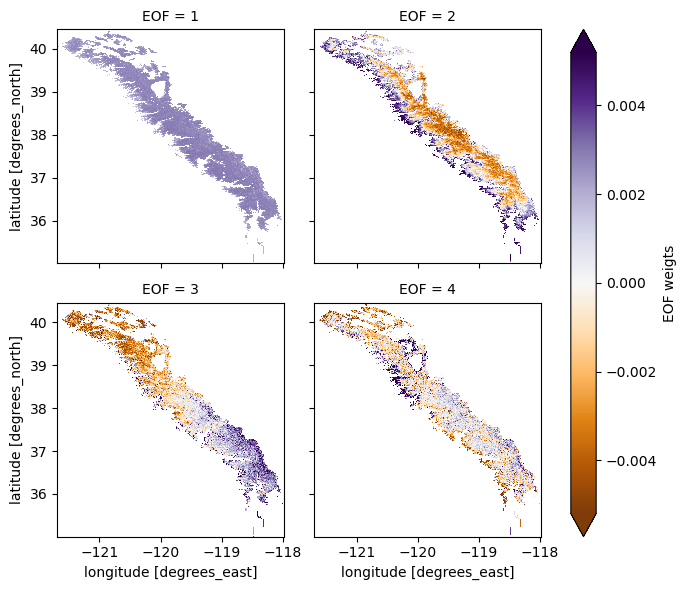

In [35]:
firstFour = U_spatial_eof_anom_sd.isel(EOF=slice(0, 4)).copy()

g = firstFour.plot.pcolormesh(
    x="x",
    y="y",
    col="EOF",
    col_wrap=2,
    robust=True,
    cmap="PuOr",
    cbar_kwargs={"label": "EOF weigts"},
)

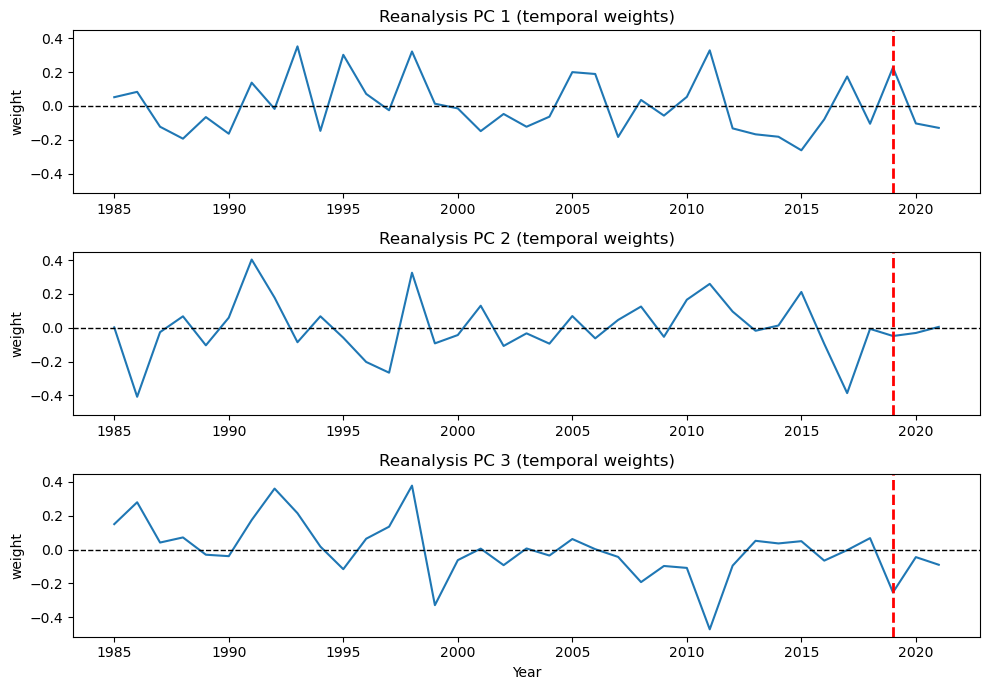

In [48]:
#Plot first PC (V)
f, ax = plt.subplots(3,1, sharex=False, sharey=True, figsize=(10,7))
i=0
for row in range(3): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V_anom_sd[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i+1} (temporal weights)')
    ax[row].axhline(0, color='black', linestyle='--', linewidth=1)
    i+=1

ax[2].set_xlabel('Year')

for ax in plt.gcf().axes:
    ax.axvline(2019, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

### Plot the SWE - fSCA residual versus PC2 Weights:

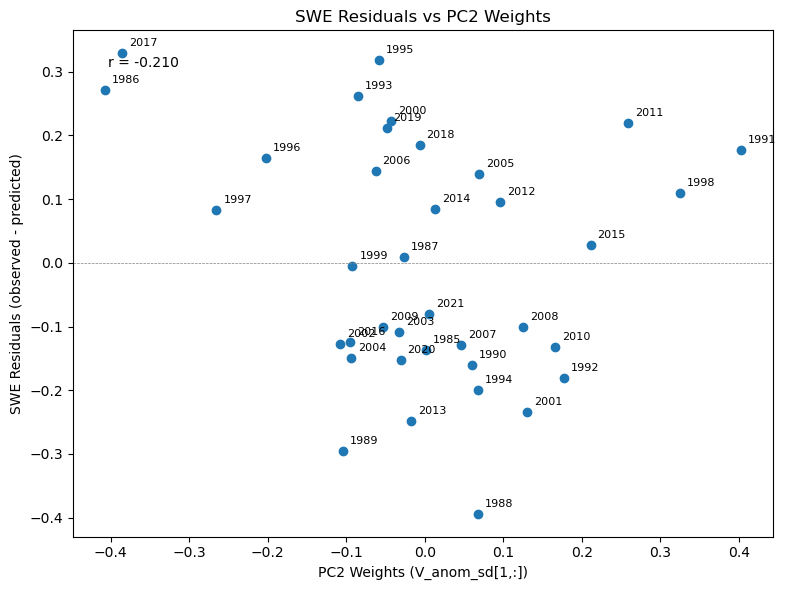

In [150]:
# Plot residuals vs PC2 weights
# Get PC2 weights for matching years
pc2_weights = V_anom_sd[1, :]

# Get years from combined_df and match to PC2 weights
# PC2 weights correspond to years in years_array
residual_years = combined_df.index.values

# Find indices of residual years in years_array
pc2_for_residuals = []
for yr in residual_years:
    if yr in years_array:
        idx = list(years_array).index(yr)
        pc2_for_residuals.append(pc2_weights[idx])
    else:
        pc2_for_residuals.append(np.nan)

pc2_for_residuals = np.array(pc2_for_residuals)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pc2_for_residuals, combined_df['residuals'].values)

# Add year labels
for i, year in enumerate(residual_years):
    ax.annotate(str(year), (pc2_for_residuals[i], combined_df['residuals'].values[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('PC2 Weights (V_anom_sd[1,:])')
ax.set_ylabel('SWE Residuals (observed - predicted)')
ax.set_title('SWE Residuals vs PC2 Weights')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

# Calculate and display correlation
valid_mask = ~np.isnan(pc2_for_residuals)
corr_pc2_resid = np.corrcoef(pc2_for_residuals[valid_mask], combined_df['residuals'].values[valid_mask])[0, 1]
ax.text(0.05, 0.95, f'r = {corr_pc2_resid:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()

In [36]:
mean_sca_area_weighted

<xarray.DataArray (time: 13514)> Size: 108kB
array([0.0213501 , 0.15418853, 0.09985778, ..., 0.04285038, 0.02739999,
       0.00016521], shape=(13514,))
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

In [62]:
mean_sca_area_weighted_april1 = mean_sca_area_weighted.sel(time=( (mean_sca_area_weighted['time'].dt.month == 4) & (mean_sca_area_weighted['time'].dt.day == 1) ))

In [39]:
mean_sca_area_weighted_april1.values

array([0.92987773, 0.8366259 , 0.78689784, 0.56681246, 0.82877699,
       0.67637885, 0.96067859, 0.86037909, 0.95313998, 0.7334687 ,
       0.95742761, 0.91870386, 0.78178141, 0.9574421 , 0.90110555,
       0.8897128 , 0.72832608, 0.83929037, 0.7451694 , 0.77397599,
       0.95014919, 0.95902079, 0.57001966, 0.92319798, 0.86468716,
       0.94928986, 0.9605561 , 0.85697274, 0.62252752, 0.70697337,
       0.16051238, 0.78902346, 0.9204447 , 0.8538398 , 0.95292371,
       0.82115847, 0.75482786])

Text(0.5, 1.0, 'PC2 Temporal Weight vs. Mean SCA on April 1')

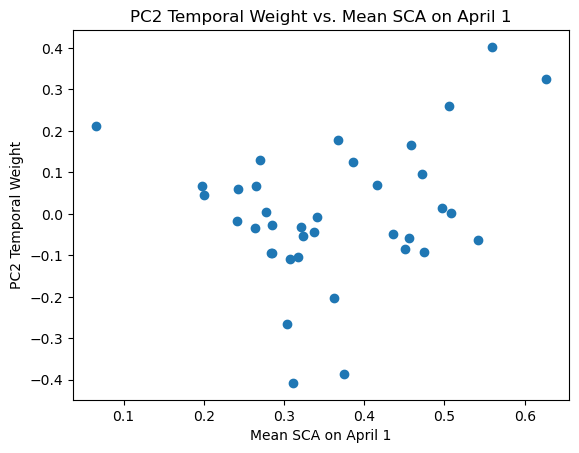

In [63]:
fig, ax = plt.subplots()
ax.scatter(mean_sca_area_weighted_april1.values, V_anom_sd[1,:])
ax.set_xlabel('Mean SCA on April 1')
ax.set_ylabel('PC2 Temporal Weight')
ax.set_title('PC2 Temporal Weight vs. Mean SCA on April 1')

Text(0.5, 1.0, 'PC2 Temporal Weight vs. Mean SCA on April 1')

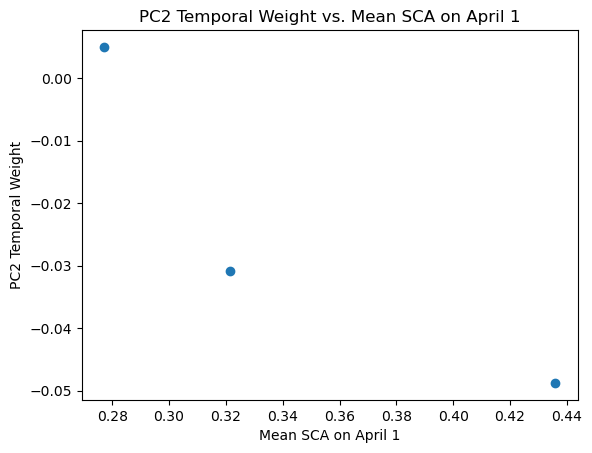

In [64]:
fig, ax = plt.subplots()
ax.scatter(mean_sca_area_weighted_april1.sel(time=slice('2019-04-01', '2021-04-01')).values, V_anom_sd[1,-3:])
ax.set_xlabel('Mean SCA on April 1')
ax.set_ylabel('PC2 Temporal Weight')
ax.set_title('PC2 Temporal Weight vs. Mean SCA on April 1')

Text(0.5, 1.0, 'PC2 Temporal Weight vs. Mean SCA on April 1')

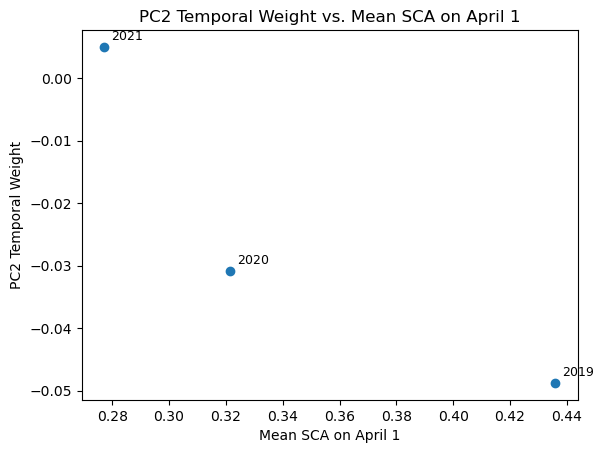

In [65]:
fig, ax = plt.subplots()
x = mean_sca_area_weighted_april1.sel(time=slice('2019-04-01', '2021-04-01'))
y = V_anom_sd[1,-3:]
ax.scatter(x.values, y)

# Add year labels to each point
for i, t in enumerate(x.time.values):
    year = pd.Timestamp(t).year
    ax.annotate(str(year), (x.values[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=9)

ax.set_xlabel('Mean SCA on April 1')
ax.set_ylabel('PC2 Temporal Weight')
ax.set_title('PC2 Temporal Weight vs. Mean SCA on April 1')

Text(0.5, 1.0, 'PC2 Temporal Weight vs. Mean SCA on April 1')

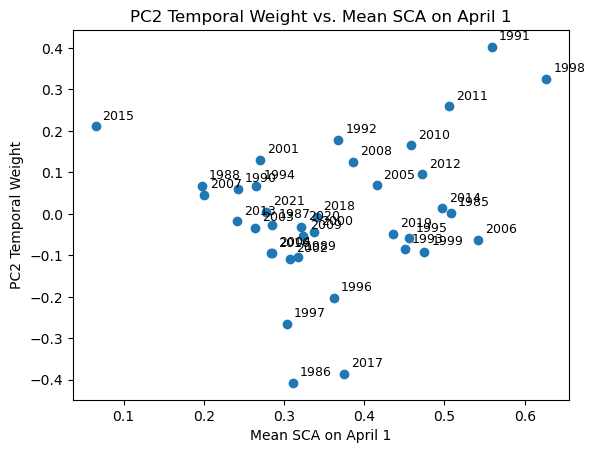

In [66]:
fig, ax = plt.subplots()
x = mean_sca_area_weighted_april1
y = V_anom_sd[1,:]
ax.scatter(x.values, y)

# Add year labels to each point
for i, t in enumerate(x.time.values):
    year = pd.Timestamp(t).year
    ax.annotate(str(year), (x.values[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=9)

ax.set_xlabel('Mean SCA on April 1')
ax.set_ylabel('PC2 Temporal Weight')
ax.set_title('PC2 Temporal Weight vs. Mean SCA on April 1')

Text(0.5, 1.0, 'PC3 Temporal Weight vs. Mean SCA on April 1')

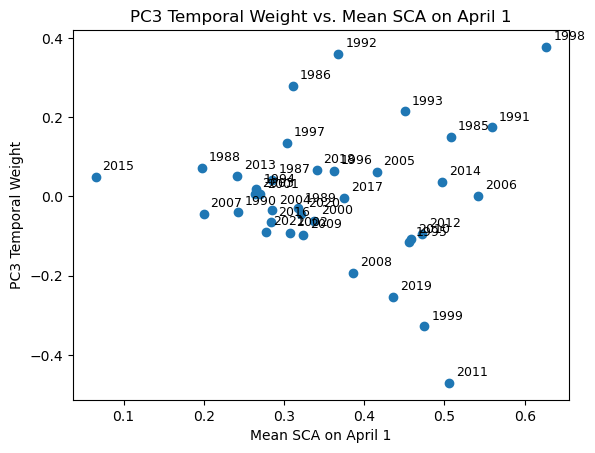

In [139]:
fig, ax = plt.subplots()
x = mean_sca_area_weighted_april1
y = V_anom_sd[2,:]
ax.scatter(x.values, y)

# Add year labels to each point
for i, t in enumerate(x.time.values):
    year = pd.Timestamp(t).year
    ax.annotate(str(year), (x.values[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=9)

ax.set_xlabel('Mean SCA on April 1')
ax.set_ylabel('PC3 Temporal Weight')
ax.set_title('PC3 Temporal Weight vs. Mean SCA on April 1')

### Try the same think for a rolling median over 7 days:

In [68]:
# Try running average of fsca next:

sca_rolling_7day_median = mean_sca_area_weighted.rolling(
    time=7, 
    min_periods=1  # Allow calculation even with fewer than 14 days at the start
).median()

sca_rolling_7day_median.name = 'sca_rolling_7day_median'

time_numeric_sca = mean_sca_area_weighted['time'].values.astype('datetime64[ns]').astype(np.int64)
time_da_sca = xr.DataArray(time_numeric_sca, dims=['time'], coords={'time': mean_sca_area_weighted['time']})
sca_rolling_7day_median_date = time_da_sca.rolling(time=7, min_periods=1, center=True).median()
sca_rolling_7day_median_date.name = 'sca_rolling_7day_median_date'

# Calculate the median date for the rolling windowsca_rolling_7day_median_date = xr.DataArray(sca_rolling_7day_median_date, dims=['time'], coords={'time': mean_sca_area_weighted['time']})


sca_rolling_7day_median_date = sca_rolling_7day_median_date.values.astype('datetime64[ns]')




In [73]:
sca_rolling_7day_median

<xarray.DataArray 'sca_rolling_7day_median' (time: 13514)> Size: 108kB
array([9.28828377e-03, 3.31833273e-02, 3.60025719e-02, ...,
       1.64359480e-05, 1.98047341e-05, 1.98047341e-05], shape=(13514,))
Coordinates:
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0

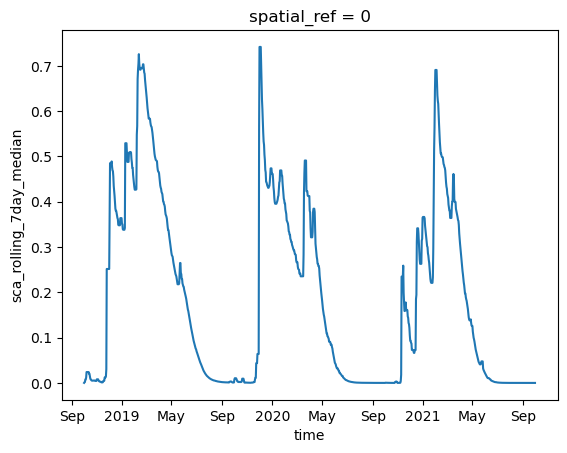

In [77]:
sca_rolling_7day_median.sel(time=slice('2018-10-01','2021-09-30')).plot()

In [74]:
mean_sca_area_weighted_april1_rolling = sca_rolling_7day_median.sel(time=( (sca_rolling_7day_median['time'].dt.month == 4) & (sca_rolling_7day_median['time'].dt.day == 1) ))

Text(0.5, 1.0, 'PC2 Temporal Weight vs. Mean SCA on April 1 (7-day rolling median)')

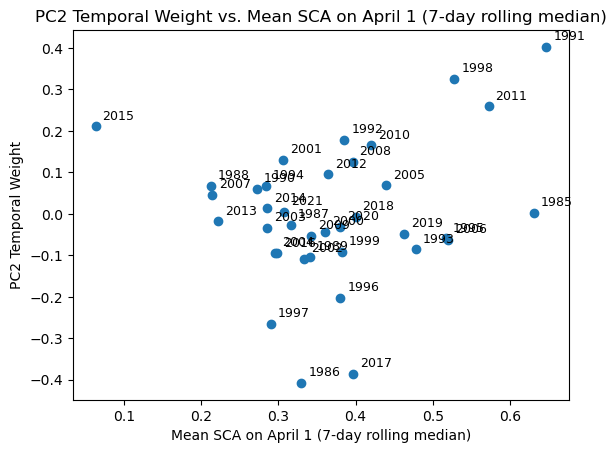

In [78]:
fig, ax = plt.subplots()
x = mean_sca_area_weighted_april1_rolling
y = V_anom_sd[1,:]
ax.scatter(x.values, y)

# Add year labels to each point
for i, t in enumerate(x.time.values):
    year = pd.Timestamp(t).year
    ax.annotate(str(year), (x.values[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=9)

ax.set_xlabel('Mean SCA on April 1 (7-day rolling median)')
ax.set_ylabel('PC2 Temporal Weight')
ax.set_title('PC2 Temporal Weight vs. Mean SCA on April 1 (7-day rolling median)')

So the rolling 7 day average didn't help. Moving on to the boxes

### Make boxes of regions where fsca might be more informative:

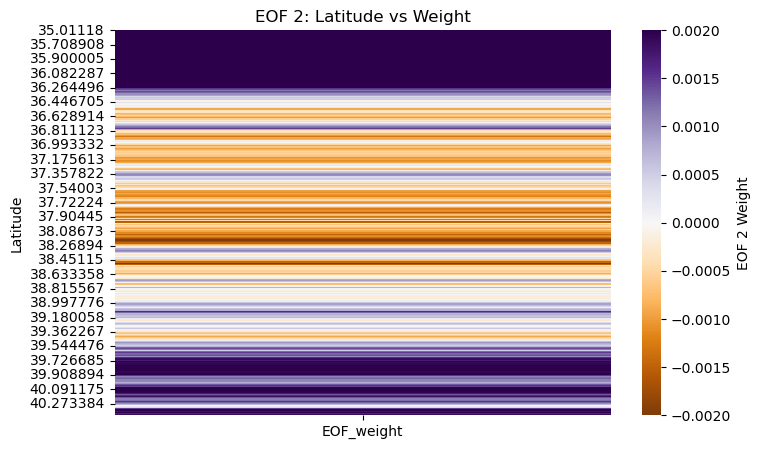

In [87]:
import seaborn as sns

# Select EOF 2 (Python is 0-indexed, so EOF=2 is index 1)
eof2 = U_spatial_eof_anom_sd.sel(EOF=2)

# Prepare data for seaborn: flatten to DataFrame with latitude (y) and weight
df = eof2.to_dataframe(name='EOF_weight').reset_index()

# Plot heatmap of latitude vs EOF weight
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.pivot_table(index='y', values='EOF_weight'),
    cmap='PuOr',
    robust=True,
    vmin=-0.002, vmax=0.002,
    cbar_kws={'label': 'EOF 2 Weight'}
)
plt.title('EOF 2: Latitude vs Weight')
plt.ylabel('Latitude')
plt.xlabel('')
plt.show()

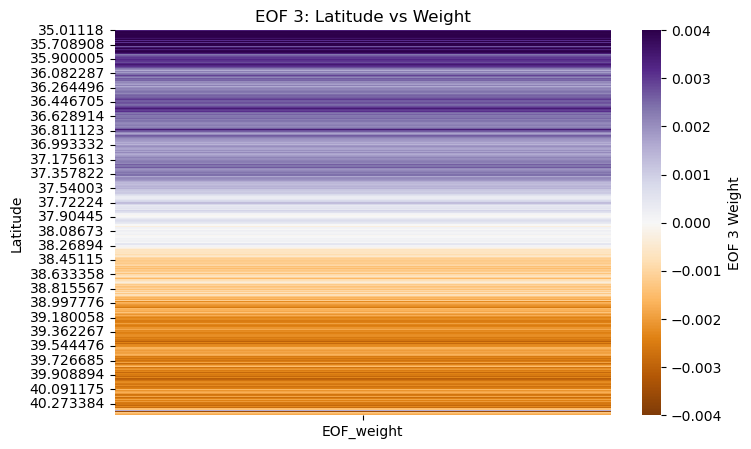

In [84]:


# Select EOF 2 (Python is 0-indexed, so EOF=2 is index 1)
eof3 = U_spatial_eof_anom_sd.sel(EOF=3)

# Prepare data for seaborn: flatten to DataFrame with latitude (y) and weight
df = eof3.to_dataframe(name='EOF_weight').reset_index()

# Plot heatmap of latitude vs EOF weight
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.pivot_table(index='y', values='EOF_weight'),
    cmap='PuOr',
    robust=True,
    vmin=-0.004, vmax=0.004,
    cbar_kws={'label': 'EOF 3 Weight'}
)
plt.title('EOF 3: Latitude vs Weight')
plt.ylabel('Latitude')
plt.xlabel('')
plt.show()

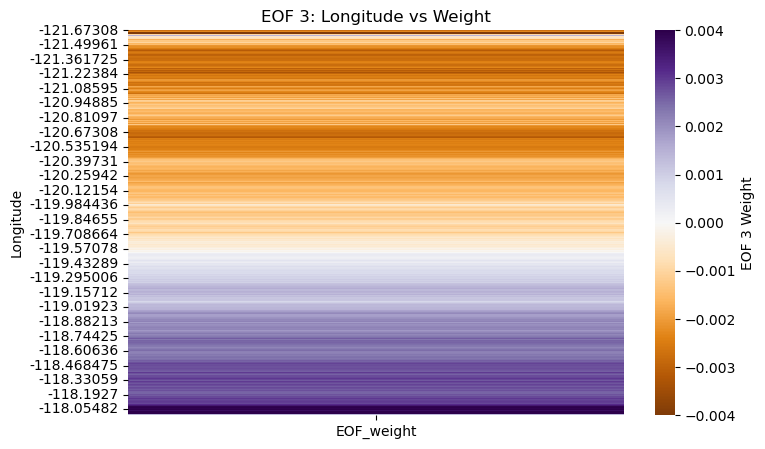

In [89]:


# Select EOF 2 (Python is 0-indexed, so EOF=2 is index 1)
eof3 = U_spatial_eof_anom_sd.sel(EOF=3)

# Prepare data for seaborn: flatten to DataFrame with latitude (y) and weight
df = eof3.to_dataframe(name='EOF_weight').reset_index()

# Plot heatmap of latitude vs EOF weight
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.pivot_table(index='x',values='EOF_weight'),
    cmap='PuOr',
    robust=True,
    vmin=-0.004,
    vmax=0.004,
    cbar_kws={'label': 'EOF 3 Weight'}
)
plt.title('EOF 3: Longitude vs Weight')
plt.ylabel('Longitude')
plt.xlabel('')
plt.show()

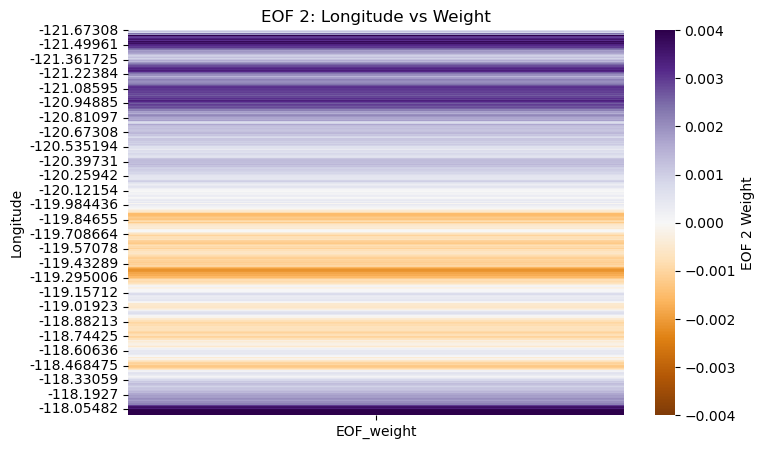

In [92]:


# Select EOF 2 (Python is 0-indexed, so EOF=2 is index 1)
eof2 = U_spatial_eof_anom_sd.sel(EOF=2)

# Prepare data for seaborn: flatten to DataFrame with latitude (y) and weight
df = eof2.to_dataframe(name='EOF_weight').reset_index()

# Plot heatmap of latitude vs EOF weight
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.pivot_table(index='x',values='EOF_weight'),
    cmap='PuOr',
    robust=True,
    vmin=-0.004,
    vmax=0.004,
    cbar_kws={'label': 'EOF 2 Weight'}
)
plt.title('EOF 2: Longitude vs Weight')
plt.ylabel('Longitude')
plt.xlabel('')
plt.show()

In [ ]:
# box 1 latitude cutoff: 36.26
# box 3 latitude cutoff: 39.6
# box 2 latitude bounds: 38.26, 38

Sierras bounds: minx=-121.95, miny=34.82, maxx=-117.86, maxy=40.45


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_4697/1532219410.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_4697/1532219410.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, 'Bounding Boxes within Sierras')

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


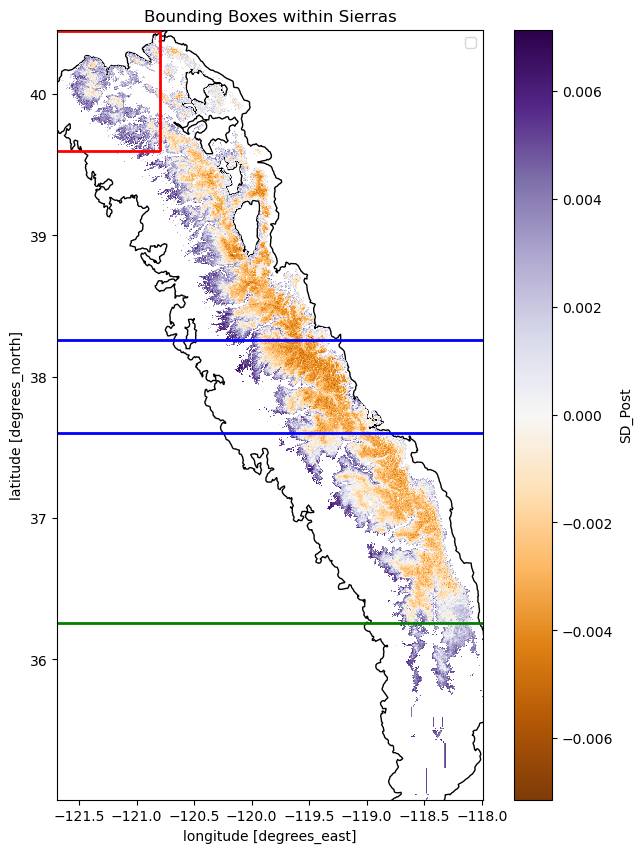

In [99]:
from shapely.geometry import box

# Get the bounds of the sierras polygon
minx, miny, maxx, maxy = sierras.total_bounds
print(f"Sierras bounds: minx={minx:.2f}, miny={miny:.2f}, maxx={maxx:.2f}, maxy={maxy:.2f}")

# Box 1: Southern boundary at 39.6, extends to the northern extent of sierras
box1 = gpd.GeoDataFrame(geometry=[box(minx, 39.6, -120.8, maxy)], crs=sierras.crs)

# Box 2: Northern boundary at 38.26, southern boundary at 38
box2 = gpd.GeoDataFrame(geometry=[box(minx, 37.6, maxx, 38.26)], crs=sierras.crs)

# Box 3: Northern boundary at 36.26, extends from the southern extent of sierras
box3 = gpd.GeoDataFrame(geometry=[box(minx, miny, maxx, 36.26)], crs=sierras.crs)

# Plot to visualize
fig, ax = plt.subplots(figsize=(8, 10))
sierras.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
U_spatial_eof_anom_sd.sel( EOF=2).plot(ax=ax, cmap='PuOr')
box1.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Box 1 (south @ 39.6)')
box2.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, label='Box 2 (38.0-38.26)')
box3.plot(ax=ax, facecolor='none', edgecolor='green', linewidth=2, label='Box 3 (north @ 36.26)')
ax.legend()
ax.set_title('Bounding Boxes within Sierras')

Sierras bounds: minx=-121.95, miny=34.82, maxx=-117.86, maxy=40.45


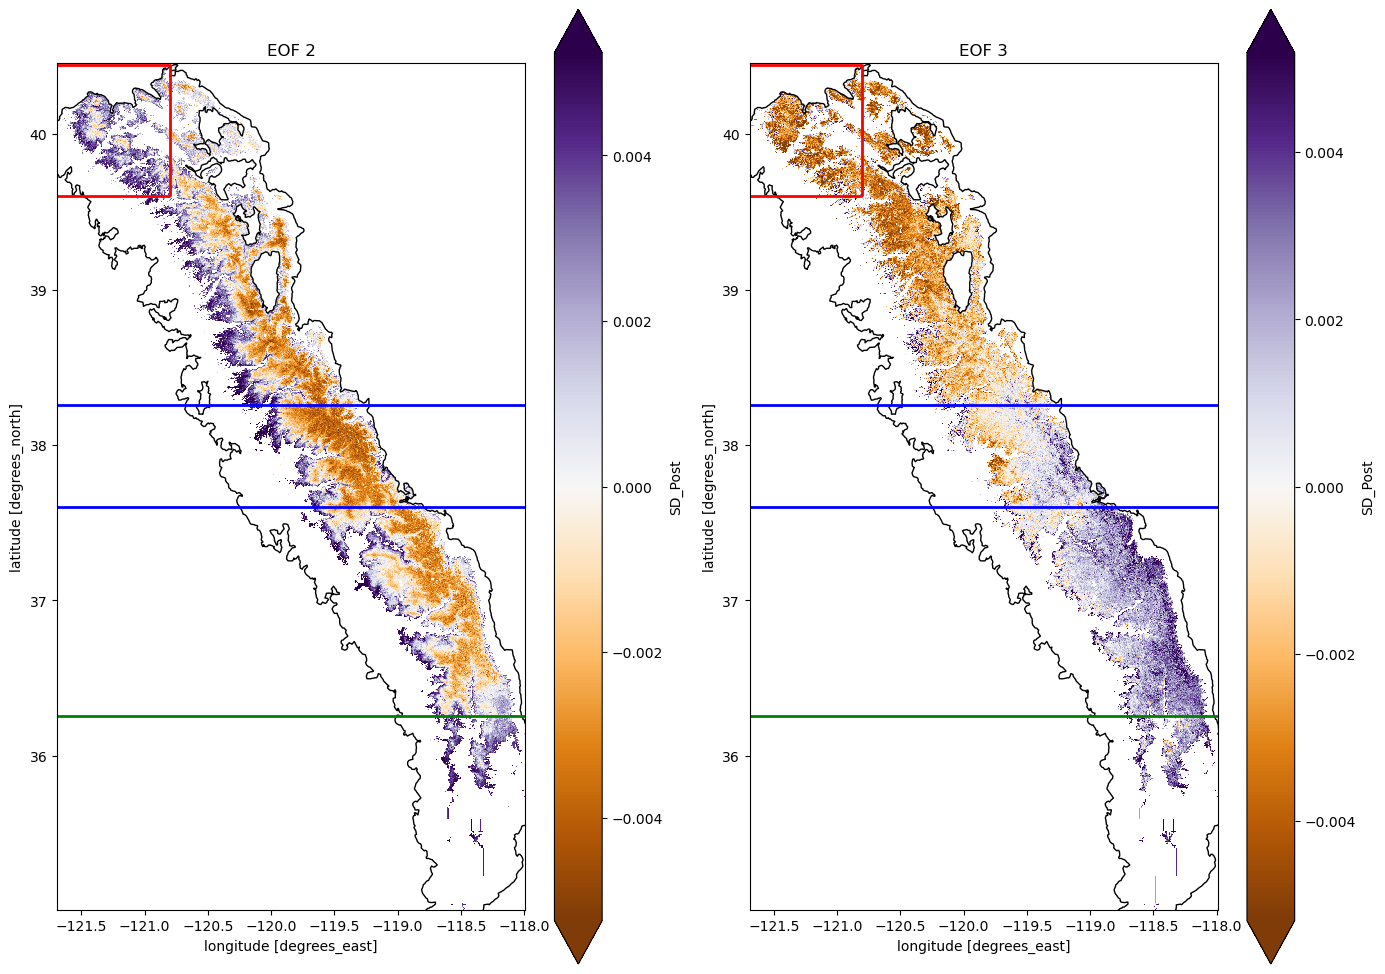

In [100]:
from shapely.geometry import box

# Get the bounds of the sierras polygon
minx, miny, maxx, maxy = sierras.total_bounds
print(f"Sierras bounds: minx={minx:.2f}, miny={miny:.2f}, maxx={maxx:.2f}, maxy={maxy:.2f}")

# Box 1: Southern boundary at 39.6, extends to the northern extent of sierras
box1 = gpd.GeoDataFrame(geometry=[box(minx, 39.6, -120.8, maxy)], crs=sierras.crs)

# Box 2: Northern boundary at 38.26, southern boundary at 38
box2 = gpd.GeoDataFrame(geometry=[box(minx, 37.6, maxx, 38.26)], crs=sierras.crs)

# Box 3: Northern boundary at 36.26, extends from the southern extent of sierras
box3 = gpd.GeoDataFrame(geometry=[box(minx, miny, maxx, 36.26)], crs=sierras.crs)

# Plot side by side with EOF 2 and EOF 3
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Left plot: EOF 2
U_spatial_eof_anom_sd.sel(EOF=2).plot(ax=axes[0], cmap='PuOr', robust=True)
sierras.plot(ax=axes[0], facecolor='none', edgecolor='black', linewidth=1)
box1.plot(ax=axes[0], facecolor='none', edgecolor='red', linewidth=2)
box2.plot(ax=axes[0], facecolor='none', edgecolor='blue', linewidth=2)
box3.plot(ax=axes[0], facecolor='none', edgecolor='green', linewidth=2)
#axes[0].legend()
axes[0].set_title('EOF 2')

# Right plot: EOF 3
U_spatial_eof_anom_sd.sel(EOF=3).plot(ax=axes[1], cmap='PuOr', robust=True)
sierras.plot(ax=axes[1], facecolor='none', edgecolor='black', linewidth=1)
box1.plot(ax=axes[1], facecolor='none', edgecolor='red', linewidth=2)
box2.plot(ax=axes[1], facecolor='none', edgecolor='blue', linewidth=2)
box3.plot(ax=axes[1], facecolor='none', edgecolor='green', linewidth=2)
#axes[1].legend()
axes[1].set_title('EOF 3')

plt.tight_layout()

In [122]:
miny

np.float64(34.81861111111108)

Sierras bounds: minx=-121.95, miny=34.82, maxx=-117.86, maxy=40.45


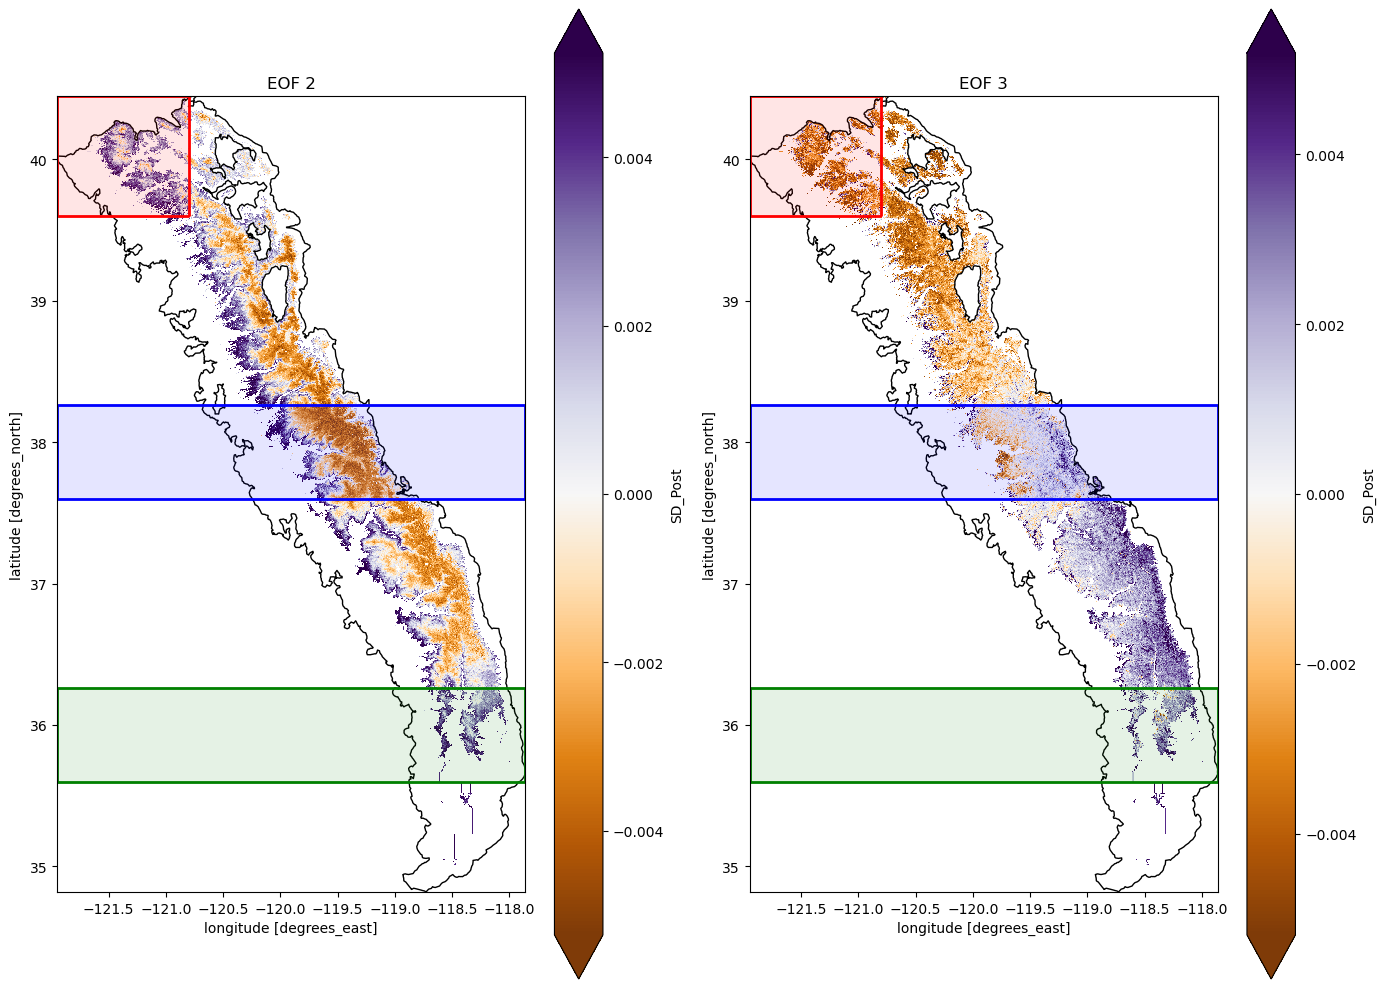

In [123]:
from shapely.geometry import box

# Get the bounds of the sierras polygon
minx, miny, maxx, maxy = sierras.total_bounds
print(f"Sierras bounds: minx={minx:.2f}, miny={miny:.2f}, maxx={maxx:.2f}, maxy={maxy:.2f}")

# Box 1: Southern boundary at 39.6, extends to the northern extent of sierras
box1 = gpd.GeoDataFrame(geometry=[box(minx, 39.6, -120.8, maxy)], crs=sierras.crs)

# Box 2: Northern boundary at 38.26, southern boundary at 38
box2 = gpd.GeoDataFrame(geometry=[box(minx, 37.6, maxx, 38.26)], crs=sierras.crs)

# Box 3: Northern boundary at 36.26, extends from the southern extent of sierras
box3 = gpd.GeoDataFrame(geometry=[box(minx, 35.6, maxx, 36.26)], crs=sierras.crs)

# Plot side by side with EOF 2 and EOF 3
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Left plot: EOF 2
U_spatial_eof_anom_sd.sel(EOF=2).plot(ax=axes[0], cmap='PuOr', robust=True)
sierras.plot(ax=axes[0], facecolor='none', edgecolor='black', linewidth=1)
box1.plot(ax=axes[0], facecolor='red', edgecolor='red', alpha=0.1, linewidth=2)
box1.plot(ax=axes[0], facecolor='none', edgecolor='red', linewidth=2)
box2.plot(ax=axes[0], facecolor='blue', edgecolor='blue', alpha=0.1, linewidth=2)
box2.plot(ax=axes[0], facecolor='none', edgecolor='blue', linewidth=2)
box3.plot(ax=axes[0], facecolor='green', edgecolor='green', alpha=0.1,linewidth=2)
box3.plot(ax=axes[0], facecolor='none', edgecolor='green', linewidth=2)
axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)
axes[0].set_title('EOF 2')

# Right plot: EOF 3
U_spatial_eof_anom_sd.sel(EOF=3).plot(ax=axes[1], cmap='PuOr', robust=True)
sierras.plot(ax=axes[1], facecolor='none', edgecolor='black', linewidth=1)
box1.plot(ax=axes[1], facecolor='red', edgecolor='red', alpha=0.1,linewidth=2)
box1.plot(ax=axes[1], facecolor='none', edgecolor='red', linewidth=2)
box2.plot(ax=axes[1], facecolor='blue', edgecolor='blue', alpha=0.1,linewidth=2)
box2.plot(ax=axes[1], facecolor='none', edgecolor='blue', linewidth=2)
box3.plot(ax=axes[1], facecolor='green', edgecolor='green', alpha=0.1,linewidth=2)
box3.plot(ax=axes[1], facecolor='none', edgecolor='green', linewidth=2)
axes[1].set_xlim(minx, maxx)
axes[1].set_ylim(miny, maxy)
axes[1].set_title('EOF 3')

plt.tight_layout()

### Now calculate the areal fsca for each box:

In [124]:
# Clip the data to each box
swe_sca_box1 = swe_sca_ds_allyrs_sierras.rio.clip(box1.geometry)
swe_sca_box2 = swe_sca_ds_allyrs_sierras.rio.clip(box2.geometry)
swe_sca_box3 = swe_sca_ds_allyrs_sierras.rio.clip(box3.geometry)

# Grid spacing in degrees
dx = abs(float(swe_sca_ds_allyrs_sierras.x[1] - swe_sca_ds_allyrs_sierras.x[0]))
dy = abs(float(swe_sca_ds_allyrs_sierras.y[1] - swe_sca_ds_allyrs_sierras.y[0]))
R = 6371000  # Earth radius in meters

# Function to calculate cell area for a given dataset
def get_cell_area(ds):
    lat = ds.y
    return (R ** 2) * np.cos(np.deg2rad(lat)) * np.deg2rad(dx) * np.deg2rad(dy)

# Calculate cell area and total area for each box
cell_area_box1 = get_cell_area(swe_sca_box1)
cell_area_box2 = get_cell_area(swe_sca_box2)
cell_area_box3 = get_cell_area(swe_sca_box3)

# Get valid masks and total areas for each box
valid_mask_box1 = ~np.isnan(swe_sca_box1.SCA_Post.isel(time=0))
valid_mask_box2 = ~np.isnan(swe_sca_box2.SCA_Post.isel(time=0))
valid_mask_box3 = ~np.isnan(swe_sca_box3.SCA_Post.isel(time=0))

total_area_box1 = (cell_area_box1 * valid_mask_box1).sum().values
total_area_box2 = (cell_area_box2 * valid_mask_box2).sum().values
total_area_box3 = (cell_area_box3 * valid_mask_box3).sum().values

print(f"Box 1 (north) area: {total_area_box1 / 1e6:.2f} km²")
print(f"Box 2 (central) area: {total_area_box2 / 1e6:.2f} km²")
print(f"Box 3 (south) area: {total_area_box3 / 1e6:.2f} km²")

Box 1 (north) area: 5695.03 km²
Box 2 (central) area: 8487.73 km²
Box 3 (south) area: 6349.13 km²


Text(0, 0.5, 'Mean SCA')

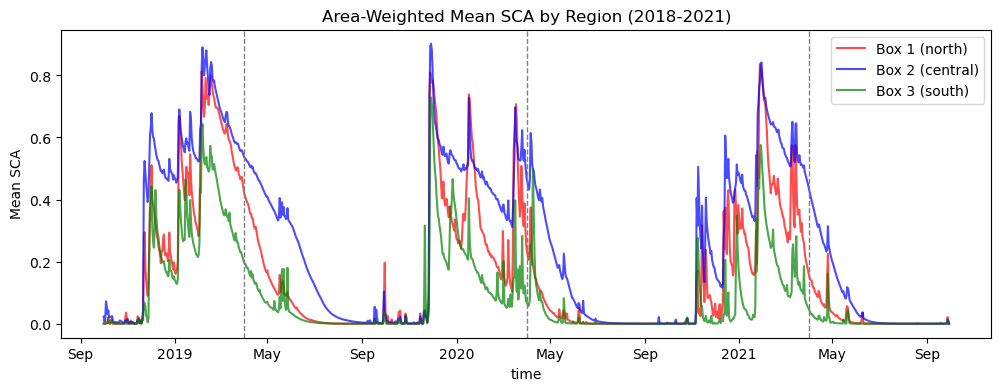

In [125]:
# Calculate area-weighted mean SCA for each day in each box
mean_sca_box1 = ((swe_sca_box1.SCA_Post * cell_area_box1).sum(dim=('y', 'x'), skipna=True) / total_area_box1).compute()
mean_sca_box2 = ((swe_sca_box2.SCA_Post * cell_area_box2).sum(dim=('y', 'x'), skipna=True) / total_area_box2).compute()
mean_sca_box3 = ((swe_sca_box3.SCA_Post * cell_area_box3).sum(dim=('y', 'x'), skipna=True) / total_area_box3).compute()

# Plot all three boxes
fig, ax = plt.subplots(figsize=(12, 4))
mean_sca_box1.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax, label='Box 1 (north)', color='red', alpha=0.7)
mean_sca_box2.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax, label='Box 2 (central)', color='blue', alpha=0.7)
mean_sca_box3.sel(time=slice('2018-10-01', '2021-09-30')).plot(ax=ax, label='Box 3 (south)', color='green', alpha=0.7)

# Add dashed vertical lines at April 1 of each year
for year in [2019, 2020, 2021]:
    ax.axvline(pd.Timestamp(f'{year}-04-01'), color='gray', linestyle='--', linewidth=1)

ax.legend()
ax.set_title('Area-Weighted Mean SCA by Region (2018-2021)')
ax.set_ylabel('Mean SCA')

In [ ]:
# Calculate centered 7-day running median for each box
mean_sca_box1_7day_median = mean_sca_box1.rolling(time=7, center=True).median()
mean_sca_box2_7day_median = mean_sca_box2.rolling(time=7, center=True).median()
mean_sca_box3_7day_median = mean_sca_box3.rolling(time=7, center=True).median()

# Calculate integrals for each box from Dec 1 - April 1 of each water year
def calculate_fsca_integral(data, water_years_unique):
    """Calculate Dec 1 - Apr 1 integral for each water year"""
    integrals = []
    wy_list = []
    
    for wy in water_years_unique:
        start_date = f'{wy-1}-12-01'
        end_date = f'{wy}-04-01'
        
        subset = data.sel(time=slice(start_date, end_date))
        subset = subset.dropna(dim='time')
        
        if len(subset) > 1:
            time_numeric = (subset['time'] - subset['time'][0]).dt.days.values.astype(float)
            integral = integrate.trapezoid(subset.values, time_numeric)
            integrals.append(integral)
            wy_list.append(wy)
    
    return wy_list, integrals

# Calculate integrals for each box
wy_box1, integrals_box1 = calculate_fsca_integral(mean_sca_box1_7day_median, water_years_unique)
wy_box2, integrals_box2 = calculate_fsca_integral(mean_sca_box2_7day_median, water_years_unique)
wy_box3, integrals_box3 = calculate_fsca_integral(mean_sca_box3_7day_median, water_years_unique)

# Add to dataframe
sierras_fsca_integral_df['box1_fsca_integral'] = pd.Series(integrals_box1, index=wy_box1)
sierras_fsca_integral_df['box2_fsca_integral'] = pd.Series(integrals_box2, index=wy_box2)
sierras_fsca_integral_df['box3_fsca_integral'] = pd.Series(integrals_box3, index=wy_box3)

sierras_fsca_integral_df

,sierras_fsca_integral,box1_fsca_integral,box2_fsca_integral,box3_fsca_integral
water_year,,,,
1985,60.412529,57.711865,72.038938,40.805782
1986,52.817956,53.351882,63.412264,23.701521
1987,39.383893,35.953924,51.214294,12.208030
1988,56.446056,62.141117,66.125450,30.864692
1989,62.812649,66.078252,73.336414,36.125022
1990,45.898409,41.955314,57.829116,17.055825
1991,43.507434,41.136821,54.490314,21.397093
1992,55.318641,50.017903,68.093258,29.427686
1993,69.485911,78.421543,77.033340,45.035370


In [155]:
sierras_fsca_integral_df['box1_box3_ratio'] = sierras_fsca_integral_df['box1_fsca_integral'] / sierras_fsca_integral_df['box3_fsca_integral']

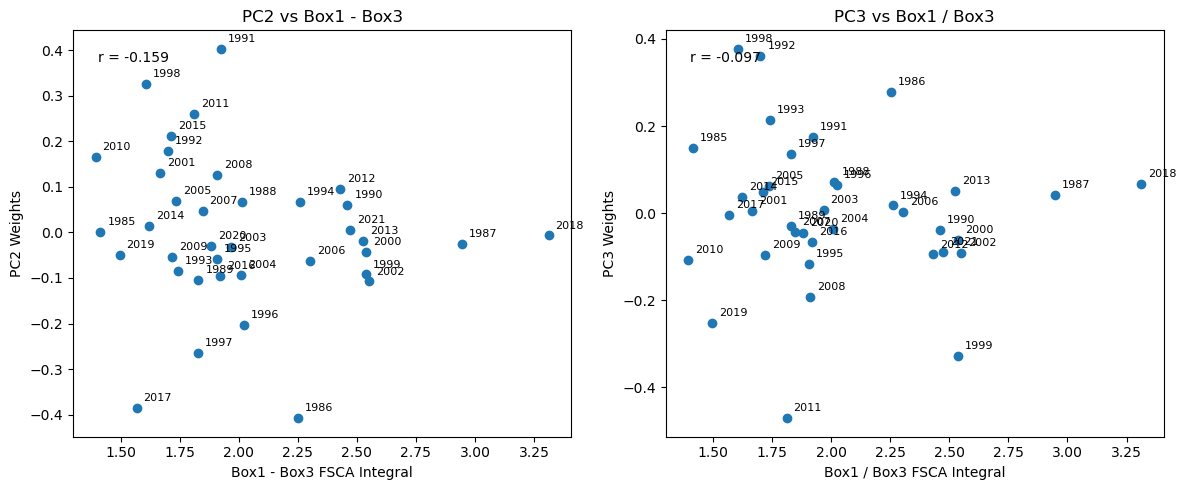

In [156]:
# Plot PC2 and PC3 weights versus box1_minus_box3
# Calculate box1_minus_box3 from the integrals in sierras_fsca_integral_df
box1_box3_ratio_integral = sierras_fsca_integral_df['box1_box3_ratio']

# Get PC2 and PC3 weights for matching years
pc2_weights_all = V_anom_sd[1, :]
pc3_weights_all = V_anom_sd[2, :]

# Match years from sierras_fsca_integral_df to years_array
pc2_matched = []
pc3_matched = []
for yr in sierras_fsca_integral_df.index:
    if yr in years_array:
        idx = list(years_array).index(yr)
        pc2_matched.append(pc2_weights_all[idx])
        pc3_matched.append(pc3_weights_all[idx])
    else:
        pc2_matched.append(np.nan)
        pc3_matched.append(np.nan)

pc2_matched = np.array(pc2_matched)
pc3_matched = np.array(pc3_matched)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PC2 vs box1_minus_box3
ax1 = axes[0]
ax1.scatter(box1_box3_ratio_integral, pc2_matched)
for i, yr in enumerate(sierras_fsca_integral_df.index):
    ax1.annotate(str(yr), (box1_box3_ratio_integral.iloc[i], pc2_matched[i]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax1.set_xlabel('Box1 - Box3 FSCA Integral')
ax1.set_ylabel('PC2 Weights')
ax1.set_title('PC2 vs Box1 - Box3')
valid_idx = ~np.isnan(pc2_matched)
corr_pc2 = np.corrcoef(box1_box3_ratio_integral.values[valid_idx], pc2_matched[valid_idx])[0, 1]
ax1.text(0.05, 0.95, f'r = {corr_pc2:.3f}', transform=ax1.transAxes, fontsize=10, verticalalignment='top')

# PC3 vs box1_minus_box3
ax2 = axes[1]
ax2.scatter(box1_box3_ratio_integral, pc3_matched)
for i, yr in enumerate(sierras_fsca_integral_df.index):
    ax2.annotate(str(yr), (box1_box3_ratio_integral.iloc[i], pc3_matched[i]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax2.set_xlabel('Box1 / Box3 FSCA Integral')
ax2.set_ylabel('PC3 Weights')
ax2.set_title('PC3 vs Box1 / Box3')
corr_pc3 = np.corrcoef(box1_box3_ratio_integral.values[valid_idx], pc3_matched[valid_idx])[0, 1]
ax2.text(0.05, 0.95, f'r = {corr_pc3:.3f}', transform=ax2.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()

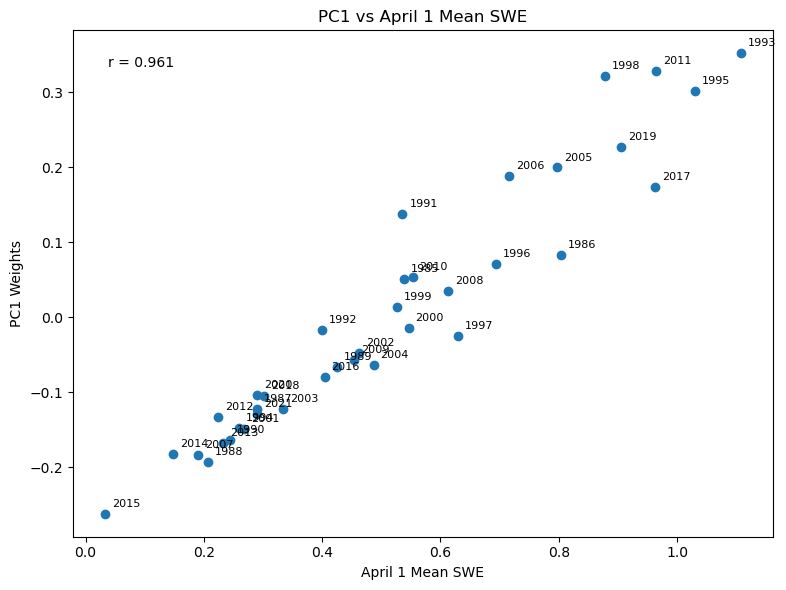

In [154]:
# Plot PC1 weights versus April 1 mean SWE
pc1_weights_all = V_anom_sd[0, :]

# Match years from combined_df to years_array
pc1_matched = []
for yr in combined_df.index:
    if yr in years_array:
        idx = list(years_array).index(yr)
        pc1_matched.append(pc1_weights_all[idx])
    else:
        pc1_matched.append(np.nan)

pc1_matched = np.array(pc1_matched)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(combined_df['april1_mean_swe'], pc1_matched)

# Add year labels
for i, yr in enumerate(combined_df.index):
    ax.annotate(str(yr), (combined_df['april1_mean_swe'].iloc[i], pc1_matched[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('April 1 Mean SWE')
ax.set_ylabel('PC1 Weights')
ax.set_title('PC1 vs April 1 Mean SWE')

# Calculate and display correlation
valid_idx = ~np.isnan(pc1_matched)
corr_pc1 = np.corrcoef(combined_df['april1_mean_swe'].values[valid_idx], pc1_matched[valid_idx])[0, 1]
ax.text(0.05, 0.95, f'r = {corr_pc1:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()

In [161]:
# Multiple Linear Regression to predict PC weights from FSCA metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
import numpy as np

# Build feature matrix from FSCA data
# Match years between sierras_fsca_integral_df and years_array
common_years = [yr for yr in sierras_fsca_integral_df.index if yr in years_array]

# Get PC weights for common years
pc1_target = []
pc2_target = []
pc3_target = []
for yr in common_years:
    idx = list(years_array).index(yr)
    pc1_target.append(V_anom_sd[0, idx])
    pc2_target.append(V_anom_sd[1, idx])
    pc3_target.append(V_anom_sd[2, idx])

pc1_target = np.array(pc1_target)
pc2_target = np.array(pc2_target)
pc3_target = np.array(pc3_target)

# Build feature matrix
fsca_df = sierras_fsca_integral_df.loc[common_years].copy()

# Add derived features
fsca_df['box1_minus_box3'] = fsca_df['box1_fsca_integral'] - fsca_df['box3_fsca_integral']
fsca_df['box1_over_box3'] = fsca_df['box1_fsca_integral'] / fsca_df['box3_fsca_integral']
fsca_df['box2_normalized'] = fsca_df['box2_fsca_integral'] / fsca_df['sierras_fsca_integral']
fsca_df['box1_normalized'] = fsca_df['box1_fsca_integral'] / fsca_df['sierras_fsca_integral']
fsca_df['box3_normalized'] = fsca_df['box3_fsca_integral'] / fsca_df['sierras_fsca_integral']
fsca_df['normalized_box1_over_box3'] = fsca_df['box1_normalized'] / fsca_df['box3_normalized']

print("Features available:")
print(fsca_df.columns.tolist())
print(f"\nNumber of years: {len(common_years)}")
print(f"Years: {common_years}")

Features available:
['sierras_fsca_integral', 'box1_fsca_integral', 'box2_fsca_integral', 'box3_fsca_integral', 'box1_minus_box3', 'box1_box3_ratio', 'box1_over_box3', 'box2_normalized', 'box1_normalized', 'box3_normalized', 'normalized_box1_over_box3']

Number of years: 37
Years: [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]


In [162]:
# Define feature sets for each PC based on physical interpretation
# PC1: Total snow amount -> use sierras_fsca_integral
# PC2: Elevation gradient -> use box2 (mid-elevation) controlled for total
# PC3: North-south split -> use box1-box3 difference controlled for total

# Feature matrices for each PC
X_pc1 = fsca_df[['sierras_fsca_integral']].values
X_pc2 = fsca_df[['sierras_fsca_integral', 'box2_normalized']].values
X_pc3 = fsca_df[['sierras_fsca_integral', 'normalized_box1_over_box3']].values

# Leave-One-Out Cross-Validation for each PC
loo = LeaveOneOut()

def loocv_regression(X, y, feature_names):
    """Perform LOOCV and return predictions, actual values, and metrics"""
    predictions = np.zeros(len(y))
    
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        predictions[test_idx] = model.predict(X_test)
    
    # Fit final model on all data for coefficients
    final_model = LinearRegression()
    final_model.fit(X, y)
    
    r2_cv = r2_score(y, predictions)
    corr = np.corrcoef(y, predictions)[0, 1]
    
    return predictions, r2_cv, corr, final_model, feature_names

# Run LOOCV for each PC
print("=" * 60)
print("PC1 Prediction (Total Snow Amount)")
print("=" * 60)
pc1_pred, pc1_r2, pc1_corr, pc1_model, _ = loocv_regression(X_pc1, pc1_target, ['sierras_fsca_integral'])
print(f"Features: sierras_fsca_integral")
print(f"LOOCV R²: {pc1_r2:.4f}")
print(f"LOOCV Correlation: {pc1_corr:.4f}")
print(f"Coefficients: {pc1_model.coef_}")
print(f"Intercept: {pc1_model.intercept_:.4f}")

print("\n" + "=" * 60)
print("PC2 Prediction (Elevation Gradient)")
print("=" * 60)
pc2_pred, pc2_r2, pc2_corr, pc2_model, _ = loocv_regression(X_pc2, pc2_target, ['sierras_fsca_integral', 'box2_fsca_integral'])
print(f"Features: sierras_fsca_integral, box2_fsca_integral")
print(f"LOOCV R²: {pc2_r2:.4f}")
print(f"LOOCV Correlation: {pc2_corr:.4f}")
print(f"Coefficients: {pc2_model.coef_}")
print(f"Intercept: {pc2_model.intercept_:.4f}")

print("\n" + "=" * 60)
print("PC3 Prediction (North-South Split)")
print("=" * 60)
pc3_pred, pc3_r2, pc3_corr, pc3_model, _ = loocv_regression(X_pc3, pc3_target, ['sierras_fsca_integral', 'box1_minus_box3'])
print(f"Features: sierras_fsca_integral, box1_minus_box3")
print(f"LOOCV R²: {pc3_r2:.4f}")
print(f"LOOCV Correlation: {pc3_corr:.4f}")
print(f"Coefficients: {pc3_model.coef_}")
print(f"Intercept: {pc3_model.intercept_:.4f}")

PC1 Prediction (Total Snow Amount)
Features: sierras_fsca_integral
LOOCV R²: 0.4151
LOOCV Correlation: 0.6464
Coefficients: [0.0106268]
Intercept: -0.5463

PC2 Prediction (Elevation Gradient)
Features: sierras_fsca_integral, box2_fsca_integral
LOOCV R²: -0.1449
LOOCV Correlation: -0.3987
Coefficients: [-0.0011156   0.09947024]
Intercept: -0.0673

PC3 Prediction (North-South Split)
Features: sierras_fsca_integral, box1_minus_box3
LOOCV R²: -0.1364
LOOCV Correlation: -0.2979
Coefficients: [-0.00167975 -0.0563756 ]
Intercept: 0.2003


Text(0.5, 1.02, 'LOOCV Predicted vs Actual PC Weights')

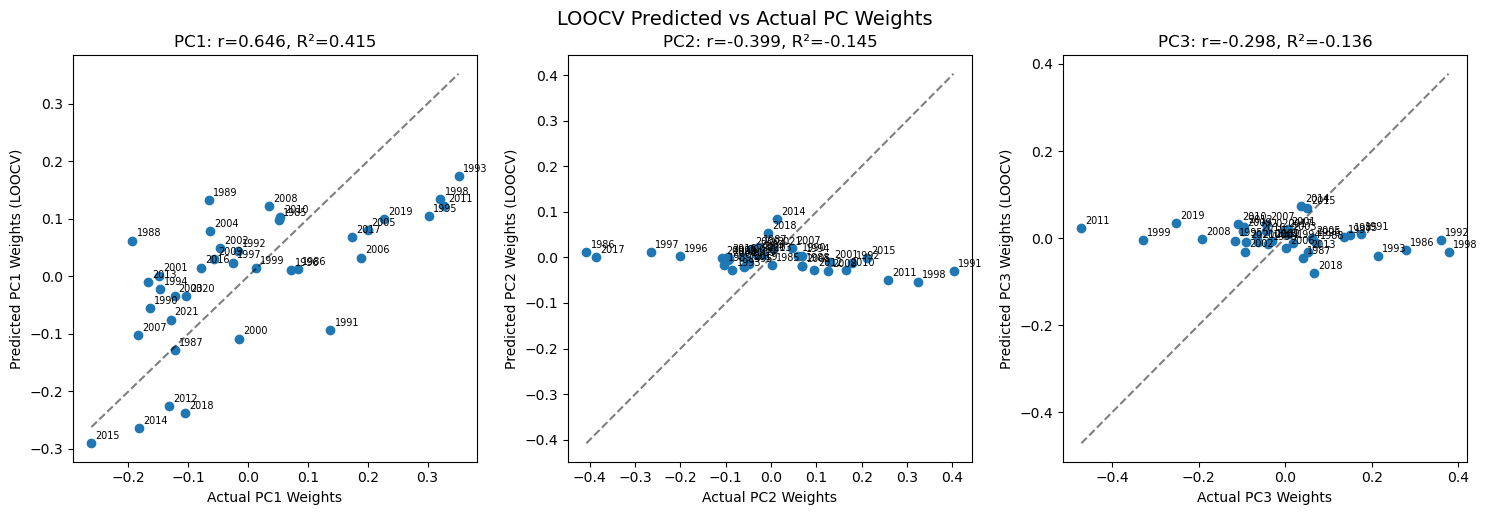

In [163]:
# Plot predicted vs actual PC weights
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PC1
ax1 = axes[0]
ax1.scatter(pc1_target, pc1_pred)
ax1.plot([pc1_target.min(), pc1_target.max()], [pc1_target.min(), pc1_target.max()], 'k--', alpha=0.5)
for i, yr in enumerate(common_years):
    ax1.annotate(str(yr), (pc1_target[i], pc1_pred[i]), textcoords="offset points", xytext=(3, 3), fontsize=7)
ax1.set_xlabel('Actual PC1 Weights')
ax1.set_ylabel('Predicted PC1 Weights (LOOCV)')
ax1.set_title(f'PC1: r={pc1_corr:.3f}, R²={pc1_r2:.3f}')

# PC2
ax2 = axes[1]
ax2.scatter(pc2_target, pc2_pred)
ax2.plot([pc2_target.min(), pc2_target.max()], [pc2_target.min(), pc2_target.max()], 'k--', alpha=0.5)
for i, yr in enumerate(common_years):
    ax2.annotate(str(yr), (pc2_target[i], pc2_pred[i]), textcoords="offset points", xytext=(3, 3), fontsize=7)
ax2.set_xlabel('Actual PC2 Weights')
ax2.set_ylabel('Predicted PC2 Weights (LOOCV)')
ax2.set_title(f'PC2: r={pc2_corr:.3f}, R²={pc2_r2:.3f}')

# PC3
ax3 = axes[2]
ax3.scatter(pc3_target, pc3_pred)
ax3.plot([pc3_target.min(), pc3_target.max()], [pc3_target.min(), pc3_target.max()], 'k--', alpha=0.5)
for i, yr in enumerate(common_years):
    ax3.annotate(str(yr), (pc3_target[i], pc3_pred[i]), textcoords="offset points", xytext=(3, 3), fontsize=7)
ax3.set_xlabel('Actual PC3 Weights')
ax3.set_ylabel('Predicted PC3 Weights (LOOCV)')
ax3.set_title(f'PC3: r={pc3_corr:.3f}, R²={pc3_r2:.3f}')

plt.tight_layout()
plt.suptitle('LOOCV Predicted vs Actual PC Weights', y=1.02, fontsize=14)

In [164]:
# Try more feature combinations to find what predicts PC2 and PC3 better
# Add additional derived features that might capture spatial patterns

# Additional derived features - motivated by physical interpretation
fsca_df['box2_anomaly'] = fsca_df['box2_fsca_integral'] - (fsca_df['box1_fsca_integral'] + fsca_df['box3_fsca_integral']) / 2
fsca_df['normalized_box2_anomaly'] = fsca_df['box2_anomaly'] / fsca_df['sierras_fsca_integral']
fsca_df['north_south_normalized_diff'] = (fsca_df['box1_fsca_integral'] - fsca_df['box3_fsca_integral']) / (fsca_df['box1_fsca_integral'] + fsca_df['box3_fsca_integral'])
fsca_df['box1_fraction'] = fsca_df['box1_fsca_integral'] / (fsca_df['box1_fsca_integral'] + fsca_df['box2_fsca_integral'] + fsca_df['box3_fsca_integral'])
fsca_df['box2_fraction'] = fsca_df['box2_fsca_integral'] / (fsca_df['box1_fsca_integral'] + fsca_df['box2_fsca_integral'] + fsca_df['box3_fsca_integral'])
fsca_df['box3_fraction'] = fsca_df['box3_fsca_integral'] / (fsca_df['box1_fsca_integral'] + fsca_df['box2_fsca_integral'] + fsca_df['box3_fsca_integral'])

print("All features available:")
for col in fsca_df.columns:
    print(f"  {col}")
    
# Test each single feature against each PC weight
print("\n" + "="*70)
print("Single Feature Correlations with PC Weights")
print("="*70)

single_features = ['sierras_fsca_integral', 'box1_fsca_integral', 'box2_fsca_integral', 
                   'box3_fsca_integral', 'box1_minus_box3', 'box1_over_box3',
                   'box2_normalized', 'box1_normalized', 'box3_normalized',
                   'normalized_box1_over_box3', 'box2_anomaly', 'normalized_box2_anomaly',
                   'north_south_normalized_diff', 'box1_fraction', 'box2_fraction', 'box3_fraction']

print(f"\n{'Feature':<30} {'PC1 corr':>10} {'PC2 corr':>10} {'PC3 corr':>10}")
print("-" * 62)

for feat in single_features:
    if feat in fsca_df.columns:
        x_vals = fsca_df[feat].values
        corr_pc1 = np.corrcoef(x_vals, pc1_target)[0, 1]
        corr_pc2 = np.corrcoef(x_vals, pc2_target)[0, 1]
        corr_pc3 = np.corrcoef(x_vals, pc3_target)[0, 1]
        print(f"{feat:<30} {corr_pc1:>10.3f} {corr_pc2:>10.3f} {corr_pc3:>10.3f}")

All features available:
  sierras_fsca_integral
  box1_fsca_integral
  box2_fsca_integral
  box3_fsca_integral
  box1_minus_box3
  box1_box3_ratio
  box1_over_box3
  box2_normalized
  box1_normalized
  box3_normalized
  normalized_box1_over_box3
  box2_anomaly
  normalized_box2_anomaly
  north_south_normalized_diff
  box1_fraction
  box2_fraction
  box3_fraction

Single Feature Correlations with PC Weights

Feature                          PC1 corr   PC2 corr   PC3 corr
--------------------------------------------------------------
sierras_fsca_integral               0.689     -0.126     -0.043
box1_fsca_integral                  0.673     -0.087     -0.066
box2_fsca_integral                  0.645     -0.139     -0.060
box3_fsca_integral                  0.702      0.030      0.017
box1_minus_box3                     0.375     -0.217     -0.156
box1_over_box3                     -0.336     -0.159     -0.097
box2_normalized                    -0.603      0.124      0.035
box1_normalize

In [165]:
# Strategy: Residualize box integrals against sierras_fsca_integral to remove PC1 signal
# This should isolate spatial pattern info (deviation from expected based on total)

# Fit linear regressions of each box integral against total, get residuals
from scipy.stats import linregress

x_total = fsca_df['sierras_fsca_integral'].values

# Box1 residuals (deviation from expected based on total snow)
slope1, int1, _, _, _ = linregress(x_total, fsca_df['box1_fsca_integral'].values)
fsca_df['box1_residual'] = fsca_df['box1_fsca_integral'] - (slope1 * x_total + int1)

# Box2 residuals
slope2, int2, _, _, _ = linregress(x_total, fsca_df['box2_fsca_integral'].values)
fsca_df['box2_residual'] = fsca_df['box2_fsca_integral'] - (slope2 * x_total + int2)

# Box3 residuals
slope3, int3, _, _, _ = linregress(x_total, fsca_df['box3_fsca_integral'].values)
fsca_df['box3_residual'] = fsca_df['box3_fsca_integral'] - (slope3 * x_total + int3)

# Create derived features from residuals
fsca_df['box1_minus_box3_resid'] = fsca_df['box1_residual'] - fsca_df['box3_residual']
fsca_df['box2_resid_vs_avg'] = fsca_df['box2_residual'] - (fsca_df['box1_residual'] + fsca_df['box3_residual']) / 2

# Test residual features
resid_features = ['box1_residual', 'box2_residual', 'box3_residual', 
                  'box1_minus_box3_resid', 'box2_resid_vs_avg']

print("="*70)
print("Residualized Feature Correlations (PC1 signal removed)")
print("="*70)
print(f"\n{'Feature':<25} {'PC1 corr':>10} {'PC2 corr':>10} {'PC3 corr':>10}")
print("-" * 57)

for feat in resid_features:
    x_vals = fsca_df[feat].values
    corr_pc1 = np.corrcoef(x_vals, pc1_target)[0, 1]
    corr_pc2 = np.corrcoef(x_vals, pc2_target)[0, 1]
    corr_pc3 = np.corrcoef(x_vals, pc3_target)[0, 1]
    print(f"{feat:<25} {corr_pc1:>10.3f} {corr_pc2:>10.3f} {corr_pc3:>10.3f}")

Residualized Feature Correlations (PC1 signal removed)

Feature                     PC1 corr   PC2 corr   PC3 corr
---------------------------------------------------------
box1_residual                  0.047      0.117     -0.085
box2_residual                 -0.170     -0.085     -0.097
box3_residual                  0.163      0.426      0.165
box1_minus_box3_resid         -0.066     -0.177     -0.165
box2_resid_vs_avg             -0.167     -0.272     -0.069


In [166]:
# Updated MLR with better features based on correlation analysis
# PC1: sierras_fsca_integral (r=0.689)
# PC2: box3_residual (r=0.426) or combine with box2_resid_vs_avg
# PC3: Still challenging - try combinations

print("="*70)
print("Updated LOOCV Regression with Better Features")
print("="*70)

# PC1 - same as before (sierras_fsca_integral)
X_pc1_new = fsca_df[['sierras_fsca_integral']].values
pc1_pred_new, pc1_r2_new, pc1_corr_new, _, _ = loocv_regression(X_pc1_new, pc1_target, ['sierras_fsca_integral'])
print(f"\nPC1 (sierras_fsca_integral only):")
print(f"  LOOCV R²: {pc1_r2_new:.4f}, Correlation: {pc1_corr_new:.4f}")

# PC2 - try different options
print(f"\nPC2 Options:")

# Option 1: box3_residual alone
X_pc2_v1 = fsca_df[['box3_residual']].values
_, r2_v1, corr_v1, _, _ = loocv_regression(X_pc2_v1, pc2_target, ['box3_residual'])
print(f"  box3_residual: LOOCV R²={r2_v1:.4f}, Corr={corr_v1:.4f}")

# Option 2: box3_residual + box2_resid_vs_avg
X_pc2_v2 = fsca_df[['box3_residual', 'box2_resid_vs_avg']].values
_, r2_v2, corr_v2, _, _ = loocv_regression(X_pc2_v2, pc2_target, ['box3_residual', 'box2_resid_vs_avg'])
print(f"  box3_residual + box2_resid_vs_avg: LOOCV R²={r2_v2:.4f}, Corr={corr_v2:.4f}")

# Option 3: box3_residual + box2_residual
X_pc2_v3 = fsca_df[['box3_residual', 'box2_residual']].values
_, r2_v3, corr_v3, _, _ = loocv_regression(X_pc2_v3, pc2_target, ['box3_residual', 'box2_residual'])
print(f"  box3_residual + box2_residual: LOOCV R²={r2_v3:.4f}, Corr={corr_v3:.4f}")

# Option 4: All residuals
X_pc2_v4 = fsca_df[['box1_residual', 'box2_residual', 'box3_residual']].values
_, r2_v4, corr_v4, _, _ = loocv_regression(X_pc2_v4, pc2_target, ['box1_residual', 'box2_residual', 'box3_residual'])
print(f"  All 3 residuals: LOOCV R²={r2_v4:.4f}, Corr={corr_v4:.4f}")

# PC3 - try different options
print(f"\nPC3 Options:")

# Option 1: box1_minus_box3_resid alone
X_pc3_v1 = fsca_df[['box1_minus_box3_resid']].values
_, r2_v1, corr_v1, _, _ = loocv_regression(X_pc3_v1, pc3_target, ['box1_minus_box3_resid'])
print(f"  box1_minus_box3_resid: LOOCV R²={r2_v1:.4f}, Corr={corr_v1:.4f}")

# Option 2: box1_residual alone (negative corr -0.085)
X_pc3_v2 = fsca_df[['box1_residual']].values
_, r2_v2, corr_v2, _, _ = loocv_regression(X_pc3_v2, pc3_target, ['box1_residual'])
print(f"  box1_residual: LOOCV R²={r2_v2:.4f}, Corr={corr_v2:.4f}")

# Option 3: All residuals
X_pc3_v3 = fsca_df[['box1_residual', 'box2_residual', 'box3_residual']].values
_, r2_v3, corr_v3, _, _ = loocv_regression(X_pc3_v3, pc3_target, ['box1_residual', 'box2_residual', 'box3_residual'])
print(f"  All 3 residuals: LOOCV R²={r2_v3:.4f}, Corr={corr_v3:.4f}")

# Option 4: box3_residual + box1_residual
X_pc3_v4 = fsca_df[['box1_residual', 'box3_residual']].values
_, r2_v4, corr_v4, _, _ = loocv_regression(X_pc3_v4, pc3_target, ['box1_residual', 'box3_residual'])
print(f"  box1_residual + box3_residual: LOOCV R²={r2_v4:.4f}, Corr={corr_v4:.4f}")

Updated LOOCV Regression with Better Features

PC1 (sierras_fsca_integral only):
  LOOCV R²: 0.4151, Correlation: 0.6464

PC2 Options:
  box3_residual: LOOCV R²=0.0947, Corr=0.3258
  box3_residual + box2_resid_vs_avg: LOOCV R²=0.0614, Corr=0.2878
  box3_residual + box2_residual: LOOCV R²=0.0674, Corr=0.2997
  All 3 residuals: LOOCV R²=0.1165, Corr=0.3792

PC3 Options:
  box1_minus_box3_resid: LOOCV R²=-0.0919, Corr=-0.1613
  box1_residual: LOOCV R²=-0.1048, Corr=-0.4720
  All 3 residuals: LOOCV R²=-0.2042, Corr=-0.2532
  box1_residual + box3_residual: LOOCV R²=-0.1373, Corr=-0.2347


In [167]:
# Check if FSCA at April 1 (same date as SWE PCs) correlates better with PC weights
# Extract April 1 FSCA values for each box/region

import pandas as pd

# Get April 1 values from the 7-day median smoothed data
april1_fsca_data = []

for wy in common_years:
    # April 1 of the water year (e.g., WY 2019 = April 1, 2019)
    april1_date = pd.Timestamp(f'{wy}-04-01')
    
    # Get nearest date from each FSCA timeseries
    try:
        # Sierra-wide
        sierra_val = mean_sca_area_weighted_7day_median.sel(time=april1_date, method='nearest').values
        
        # Boxes
        box1_val = mean_sca_box1_7day_median.sel(time=april1_date, method='nearest').values
        box2_val = mean_sca_box2_7day_median.sel(time=april1_date, method='nearest').values
        box3_val = mean_sca_box3_7day_median.sel(time=april1_date, method='nearest').values
        
        april1_fsca_data.append({
            'water_year': wy,
            'sierras_fsca_apr1': float(sierra_val),
            'box1_fsca_apr1': float(box1_val),
            'box2_fsca_apr1': float(box2_val),
            'box3_fsca_apr1': float(box3_val)
        })
    except Exception as e:
        print(f"Error for WY {wy}: {e}")

april1_fsca_df = pd.DataFrame(april1_fsca_data).set_index('water_year')

# Add derived features
april1_fsca_df['box1_minus_box3_apr1'] = april1_fsca_df['box1_fsca_apr1'] - april1_fsca_df['box3_fsca_apr1']
april1_fsca_df['box1_over_box3_apr1'] = april1_fsca_df['box1_fsca_apr1'] / april1_fsca_df['box3_fsca_apr1']
april1_fsca_df['north_south_norm_apr1'] = (april1_fsca_df['box1_fsca_apr1'] - april1_fsca_df['box3_fsca_apr1']) / \
                                          (april1_fsca_df['box1_fsca_apr1'] + april1_fsca_df['box3_fsca_apr1'])
april1_fsca_df['box2_deviation_apr1'] = april1_fsca_df['box2_fsca_apr1'] - \
                                        (april1_fsca_df['box1_fsca_apr1'] + april1_fsca_df['box3_fsca_apr1']) / 2

print("April 1 FSCA values extracted")
print(april1_fsca_df.head())

# Correlate with PC weights
print("\n" + "="*70)
print("April 1 FSCA Correlations with PC Weights")
print("="*70)
print(f"\n{'Feature':<25} {'PC1 corr':>10} {'PC2 corr':>10} {'PC3 corr':>10}")
print("-" * 57)

for col in april1_fsca_df.columns:
    x_vals = april1_fsca_df[col].values
    corr_pc1 = np.corrcoef(x_vals, pc1_target)[0, 1]
    corr_pc2 = np.corrcoef(x_vals, pc2_target)[0, 1]
    corr_pc3 = np.corrcoef(x_vals, pc3_target)[0, 1]
    print(f"{col:<25} {corr_pc1:>10.3f} {corr_pc2:>10.3f} {corr_pc3:>10.3f}")

April 1 FSCA values extracted
            sierras_fsca_apr1  box1_fsca_apr1  box2_fsca_apr1  box3_fsca_apr1  \
water_year                                                                      
1985                 0.508261        0.540056        0.650977        0.237749   
1986                 0.316771        0.187369        0.454130        0.078582   
1987                 0.295529        0.212728        0.419843        0.050543   
1988                 0.197602        0.116739        0.318084        0.025358   
1989                 0.320154        0.303184        0.406076        0.086783   

            box1_minus_box3_apr1  box1_over_box3_apr1  north_south_norm_apr1  \
water_year                                                                     
1985                    0.302307             2.271539               0.388667   
1986                    0.108787             2.384367               0.409048   
1987                    0.162186             4.208893               0.616041   
19

In [168]:
# LOOCV Regressions using April 1 FSCA values
print("="*70)
print("LOOCV Regression using April 1 FSCA Features")
print("="*70)

# PC1: sierras_fsca_apr1 (r=0.844)
X_pc1_apr1 = april1_fsca_df[['sierras_fsca_apr1']].values
pc1_pred_apr1, pc1_r2_apr1, pc1_corr_apr1, pc1_model_apr1, _ = loocv_regression(X_pc1_apr1, pc1_target, ['sierras_fsca_apr1'])
print(f"\nPC1: sierras_fsca_apr1")
print(f"  LOOCV R²: {pc1_r2_apr1:.4f}, Correlation: {pc1_corr_apr1:.4f}")

# PC2: Try different options
print(f"\nPC2 Options:")

# Option 1: box2_deviation_apr1 alone (r=-0.538)
X_pc2_v1 = april1_fsca_df[['box2_deviation_apr1']].values
_, r2_v1, corr_v1, _, _ = loocv_regression(X_pc2_v1, pc2_target, ['box2_deviation_apr1'])
print(f"  box2_deviation_apr1: LOOCV R²={r2_v1:.4f}, Corr={corr_v1:.4f}")

# Option 2: box3_fsca_apr1 alone (r=0.418)
X_pc2_v2 = april1_fsca_df[['box3_fsca_apr1']].values
_, r2_v2, corr_v2, _, _ = loocv_regression(X_pc2_v2, pc2_target, ['box3_fsca_apr1'])
print(f"  box3_fsca_apr1: LOOCV R²={r2_v2:.4f}, Corr={corr_v2:.4f}")

# Option 3: box2_deviation + box3_fsca
X_pc2_v3 = april1_fsca_df[['box2_deviation_apr1', 'box3_fsca_apr1']].values
_, r2_v3, corr_v3, _, _ = loocv_regression(X_pc2_v3, pc2_target, ['box2_deviation_apr1', 'box3_fsca_apr1'])
print(f"  box2_deviation + box3_fsca: LOOCV R²={r2_v3:.4f}, Corr={corr_v3:.4f}")

# Option 4: all boxes
X_pc2_v4 = april1_fsca_df[['box1_fsca_apr1', 'box2_fsca_apr1', 'box3_fsca_apr1']].values
_, r2_v4, corr_v4, _, _ = loocv_regression(X_pc2_v4, pc2_target, ['box1_fsca_apr1', 'box2_fsca_apr1', 'box3_fsca_apr1'])
print(f"  All 3 boxes: LOOCV R²={r2_v4:.4f}, Corr={corr_v4:.4f}")

# PC3: Try different options
print(f"\nPC3 Options:")

# Option 1: box1_minus_box3_apr1 (r=-0.411)
X_pc3_v1 = april1_fsca_df[['box1_minus_box3_apr1']].values
_, r2_v1, corr_v1, _, _ = loocv_regression(X_pc3_v1, pc3_target, ['box1_minus_box3_apr1'])
print(f"  box1_minus_box3_apr1: LOOCV R²={r2_v1:.4f}, Corr={corr_v1:.4f}")

# Option 2: north_south_norm_apr1 (r=-0.319)
X_pc3_v2 = april1_fsca_df[['north_south_norm_apr1']].values
_, r2_v2, corr_v2, _, _ = loocv_regression(X_pc3_v2, pc3_target, ['north_south_norm_apr1'])
print(f"  north_south_norm_apr1: LOOCV R²={r2_v2:.4f}, Corr={corr_v2:.4f}")

# Option 3: box1 and box3 separately
X_pc3_v3 = april1_fsca_df[['box1_fsca_apr1', 'box3_fsca_apr1']].values
_, r2_v3, corr_v3, _, _ = loocv_regression(X_pc3_v3, pc3_target, ['box1_fsca_apr1', 'box3_fsca_apr1'])
print(f"  box1 + box3: LOOCV R²={r2_v3:.4f}, Corr={corr_v3:.4f}")

# Option 4: all boxes
X_pc3_v4 = april1_fsca_df[['box1_fsca_apr1', 'box2_fsca_apr1', 'box3_fsca_apr1']].values
_, r2_v4, corr_v4, _, _ = loocv_regression(X_pc3_v4, pc3_target, ['box1_fsca_apr1', 'box2_fsca_apr1', 'box3_fsca_apr1'])
print(f"  All 3 boxes: LOOCV R²={r2_v4:.4f}, Corr={corr_v4:.4f}")

# Option 5: Combine integral and April 1 features
X_pc3_v5 = np.column_stack([
    fsca_df['sierras_fsca_integral'].values,
    april1_fsca_df['box1_minus_box3_apr1'].values
])
_, r2_v5, corr_v5, _, _ = loocv_regression(X_pc3_v5, pc3_target, ['sierras_integral', 'box1_minus_box3_apr1'])
print(f"  sierras_integral + box1_minus_box3_apr1: LOOCV R²={r2_v5:.4f}, Corr={corr_v5:.4f}")

LOOCV Regression using April 1 FSCA Features

PC1: sierras_fsca_apr1
  LOOCV R²: 0.6702, Correlation: 0.8198

PC2 Options:
  box2_deviation_apr1: LOOCV R²=0.1989, Corr=0.4545
  box3_fsca_apr1: LOOCV R²=0.0682, Corr=0.2830
  box2_deviation + box3_fsca: LOOCV R²=0.1973, Corr=0.4544
  All 3 boxes: LOOCV R²=0.2170, Corr=0.4897

PC3 Options:
  box1_minus_box3_apr1: LOOCV R²=0.0390, Corr=0.2555
  north_south_norm_apr1: LOOCV R²=-0.0452, Corr=0.1055
  box1 + box3: LOOCV R²=0.2230, Corr=0.4806
  All 3 boxes: LOOCV R²=0.2059, Corr=0.4651
  sierras_integral + box1_minus_box3_apr1: LOOCV R²=-0.0191, Corr=0.1966


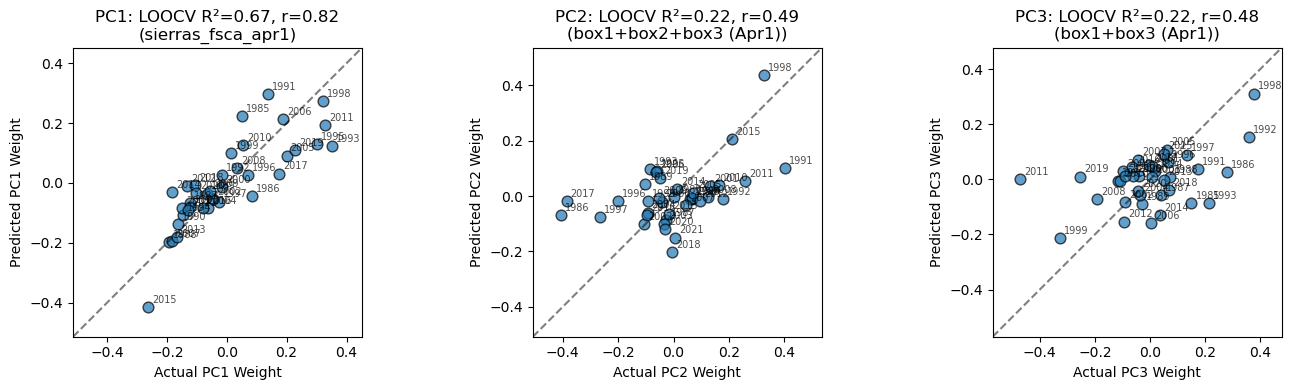


Summary: Best Models Using April 1 FSCA

PC1: sierras_fsca_apr1
     LOOCV R² = 0.670, Correlation = 0.820

PC2: box1_fsca_apr1 + box2_fsca_apr1 + box3_fsca_apr1
     LOOCV R² = 0.217, Correlation = 0.490

PC3: box1_fsca_apr1 + box3_fsca_apr1
     LOOCV R² = 0.223, Correlation = 0.481


In [169]:
# Best models using April 1 FSCA values
# PC1: sierras_fsca_apr1
# PC2: All 3 boxes
# PC3: box1 + box3

import matplotlib.pyplot as plt

# Fit best models and get predictions
X_pc1_best = april1_fsca_df[['sierras_fsca_apr1']].values
X_pc2_best = april1_fsca_df[['box1_fsca_apr1', 'box2_fsca_apr1', 'box3_fsca_apr1']].values
X_pc3_best = april1_fsca_df[['box1_fsca_apr1', 'box3_fsca_apr1']].values

pc1_pred_best, pc1_r2_best, pc1_corr_best, _, _ = loocv_regression(X_pc1_best, pc1_target, ['sierras_fsca_apr1'])
pc2_pred_best, pc2_r2_best, pc2_corr_best, _, _ = loocv_regression(X_pc2_best, pc2_target, ['box1', 'box2', 'box3'])
pc3_pred_best, pc3_r2_best, pc3_corr_best, _, _ = loocv_regression(X_pc3_best, pc3_target, ['box1', 'box3'])

# Plot predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, pc_target, pc_pred, pc_name, r2, corr, features in zip(
    axes,
    [pc1_target, pc2_target, pc3_target],
    [pc1_pred_best, pc2_pred_best, pc3_pred_best],
    ['PC1', 'PC2', 'PC3'],
    [pc1_r2_best, pc2_r2_best, pc3_r2_best],
    [pc1_corr_best, pc2_corr_best, pc3_corr_best],
    ['sierras_fsca_apr1', 'box1+box2+box3 (Apr1)', 'box1+box3 (Apr1)']
):
    ax.scatter(pc_target, pc_pred, s=60, alpha=0.7, edgecolor='black')
    
    # Add 1:1 line
    lims = [min(pc_target.min(), pc_pred.min()) - 0.1, max(pc_target.max(), pc_pred.max()) + 0.1]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='1:1 line')
    
    # Label points with years
    for i, yr in enumerate(common_years):
        ax.annotate(str(yr), (pc_target[i], pc_pred[i]), fontsize=7, alpha=0.7,
                   xytext=(3, 3), textcoords='offset points')
    
    ax.set_xlabel(f'Actual {pc_name} Weight')
    ax.set_ylabel(f'Predicted {pc_name} Weight')
    ax.set_title(f'{pc_name}: LOOCV R²={r2:.2f}, r={corr:.2f}\n({features})')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Summary: Best Models Using April 1 FSCA")
print("="*70)
print(f"\nPC1: sierras_fsca_apr1")
print(f"     LOOCV R² = {pc1_r2_best:.3f}, Correlation = {pc1_corr_best:.3f}")
print(f"\nPC2: box1_fsca_apr1 + box2_fsca_apr1 + box3_fsca_apr1")
print(f"     LOOCV R² = {pc2_r2_best:.3f}, Correlation = {pc2_corr_best:.3f}")
print(f"\nPC3: box1_fsca_apr1 + box3_fsca_apr1")
print(f"     LOOCV R² = {pc3_r2_best:.3f}, Correlation = {pc3_corr_best:.3f}")

## Hierarchical Prediction Approaches

The PCs are orthogonal by construction: PC2 captures variance orthogonal to PC1, PC3 is orthogonal to both. Our independent predictions don't leverage this structure. Two approaches:

1. **Sequential Conditioning**: Include predicted PC1 as a feature when predicting PC2, then include predicted PC1+PC2 for PC3
2. **Residualize FSCA Features**: Remove the PC1-related component from FSCA before predicting PC2/PC3

In [170]:
# Approach 1: Sequential Conditioning
# Predict PC1 first, then use predicted PC1 as feature for PC2, then PC1+PC2 for PC3
# This helps the model "focus" on residual variance

print("="*70)
print("Approach 1: Sequential Conditioning (LOOCV)")
print("="*70)
print("Use predicted PC values from previous step as features for next PC")

# Storage for predictions
pc1_pred_seq = np.zeros(len(common_years))
pc2_pred_seq = np.zeros(len(common_years))
pc3_pred_seq = np.zeros(len(common_years))

# Features: April 1 FSCA values
X_fsca = april1_fsca_df[['box1_fsca_apr1', 'box2_fsca_apr1', 'box3_fsca_apr1']].values

for train_idx, test_idx in LeaveOneOut().split(X_fsca):
    # PC1: just FSCA features
    X1_train = april1_fsca_df[['sierras_fsca_apr1']].values[train_idx]
    X1_test = april1_fsca_df[['sierras_fsca_apr1']].values[test_idx]
    y1_train = pc1_target[train_idx]
    
    model1 = LinearRegression().fit(X1_train, y1_train)
    pc1_pred_seq[test_idx] = model1.predict(X1_test)
    
    # PC2: FSCA features + predicted PC1
    # Need to get PC1 prediction for training samples too
    pc1_train_pred = model1.predict(X1_train)
    X2_train = np.column_stack([X_fsca[train_idx], pc1_train_pred])
    X2_test = np.column_stack([X_fsca[test_idx], pc1_pred_seq[test_idx]])
    y2_train = pc2_target[train_idx]
    
    model2 = LinearRegression().fit(X2_train, y2_train)
    pc2_pred_seq[test_idx] = model2.predict(X2_test)
    
    # PC3: FSCA features + predicted PC1 + predicted PC2
    pc2_train_pred = model2.predict(X2_train)
    X3_train = np.column_stack([X_fsca[train_idx], pc1_train_pred, pc2_train_pred])
    X3_test = np.column_stack([X_fsca[test_idx], pc1_pred_seq[test_idx], pc2_pred_seq[test_idx]])
    y3_train = pc3_target[train_idx]
    
    model3 = LinearRegression().fit(X3_train, y3_train)
    pc3_pred_seq[test_idx] = model3.predict(X3_test)

# Calculate metrics
from sklearn.metrics import r2_score

print("\nSequential Conditioning Results:")
for name, pred, target in [('PC1', pc1_pred_seq, pc1_target),
                            ('PC2', pc2_pred_seq, pc2_target),
                            ('PC3', pc3_pred_seq, pc3_target)]:
    r2 = r2_score(target, pred)
    corr = np.corrcoef(target, pred)[0, 1]
    print(f"  {name}: LOOCV R² = {r2:.3f}, Correlation = {corr:.3f}")

Approach 1: Sequential Conditioning (LOOCV)
Use predicted PC values from previous step as features for next PC

Sequential Conditioning Results:
  PC1: LOOCV R² = 0.670, Correlation = 0.820
  PC2: LOOCV R² = 0.313, Correlation = 0.596
  PC3: LOOCV R² = 0.149, Correlation = 0.422


In [171]:
# Approach 2: Residualize FSCA Features
# Remove variance explained by PC1 from FSCA before predicting PC2/PC3
# This extracts "spatial pattern" info orthogonal to total snow amount

print("\n" + "="*70)
print("Approach 2: Residualized FSCA Features (LOOCV)")
print("="*70)
print("Remove PC1-correlated variance from FSCA features before predicting PC2/PC3")

# Storage
pc1_pred_resid = np.zeros(len(common_years))
pc2_pred_resid = np.zeros(len(common_years))
pc3_pred_resid = np.zeros(len(common_years))

X_all = april1_fsca_df[['box1_fsca_apr1', 'box2_fsca_apr1', 'box3_fsca_apr1']].values
X_sierra = april1_fsca_df[['sierras_fsca_apr1']].values

for train_idx, test_idx in LeaveOneOut().split(X_all):
    # PC1: standard prediction
    model1 = LinearRegression().fit(X_sierra[train_idx], pc1_target[train_idx])
    pc1_pred_resid[test_idx] = model1.predict(X_sierra[test_idx])
    
    # Residualize each FSCA feature against PC1 (regress each FSCA column on PC1, take residuals)
    X_train_resid = np.zeros_like(X_all[train_idx])
    X_test_resid = np.zeros_like(X_all[test_idx])
    
    for col in range(X_all.shape[1]):
        # Fit FSCA ~ PC1 on training data
        reg = LinearRegression().fit(pc1_target[train_idx].reshape(-1,1), X_all[train_idx, col])
        # Residuals = actual FSCA - predicted FSCA from PC1
        X_train_resid[:, col] = X_all[train_idx, col] - reg.predict(pc1_target[train_idx].reshape(-1,1))
        # For test: use out-of-sample PC1 prediction
        X_test_resid[:, col] = X_all[test_idx, col] - reg.predict(pc1_pred_resid[test_idx].reshape(-1,1))
    
    # PC2: predict from residualized FSCA
    model2 = LinearRegression().fit(X_train_resid, pc2_target[train_idx])
    pc2_pred_resid[test_idx] = model2.predict(X_test_resid)
    
    # PC3: further residualize against PC2 predicted
    X_train_resid2 = np.zeros_like(X_train_resid)
    X_test_resid2 = np.zeros_like(X_test_resid)
    
    # Get PC2 predictions for training set
    pc2_train_pred = model2.predict(X_train_resid)
    
    for col in range(X_train_resid.shape[1]):
        reg2 = LinearRegression().fit(pc2_train_pred.reshape(-1,1), X_train_resid[:, col])
        X_train_resid2[:, col] = X_train_resid[:, col] - reg2.predict(pc2_train_pred.reshape(-1,1))
        X_test_resid2[:, col] = X_test_resid[:, col] - reg2.predict(pc2_pred_resid[test_idx].reshape(-1,1))
    
    model3 = LinearRegression().fit(X_train_resid2, pc3_target[train_idx])
    pc3_pred_resid[test_idx] = model3.predict(X_test_resid2)

print("\nResidualized FSCA Results:")
for name, pred, target in [('PC1', pc1_pred_resid, pc1_target),
                            ('PC2', pc2_pred_resid, pc2_target),
                            ('PC3', pc3_pred_resid, pc3_target)]:
    r2 = r2_score(target, pred)
    corr = np.corrcoef(target, pred)[0, 1]
    print(f"  {name}: LOOCV R² = {r2:.3f}, Correlation = {corr:.3f}")


Approach 2: Residualized FSCA Features (LOOCV)
Remove PC1-correlated variance from FSCA features before predicting PC2/PC3

Residualized FSCA Results:
  PC1: LOOCV R² = 0.670, Correlation = 0.820
  PC2: LOOCV R² = 0.215, Correlation = 0.556
  PC3: LOOCV R² = 0.235, Correlation = 0.499



COMPARISON: Independent vs Hierarchical Approaches

Approach          PC1 R²    PC1 r   PC2 R²    PC2 r   PC3 R²    PC3 r
-----------------------------------------------------------------------
Independent        0.670    0.820    0.217    0.490    0.223    0.481
Sequential         0.670    0.820    0.313    0.596    0.149    0.422
Residualized       0.670    0.820    0.215    0.556    0.235    0.499


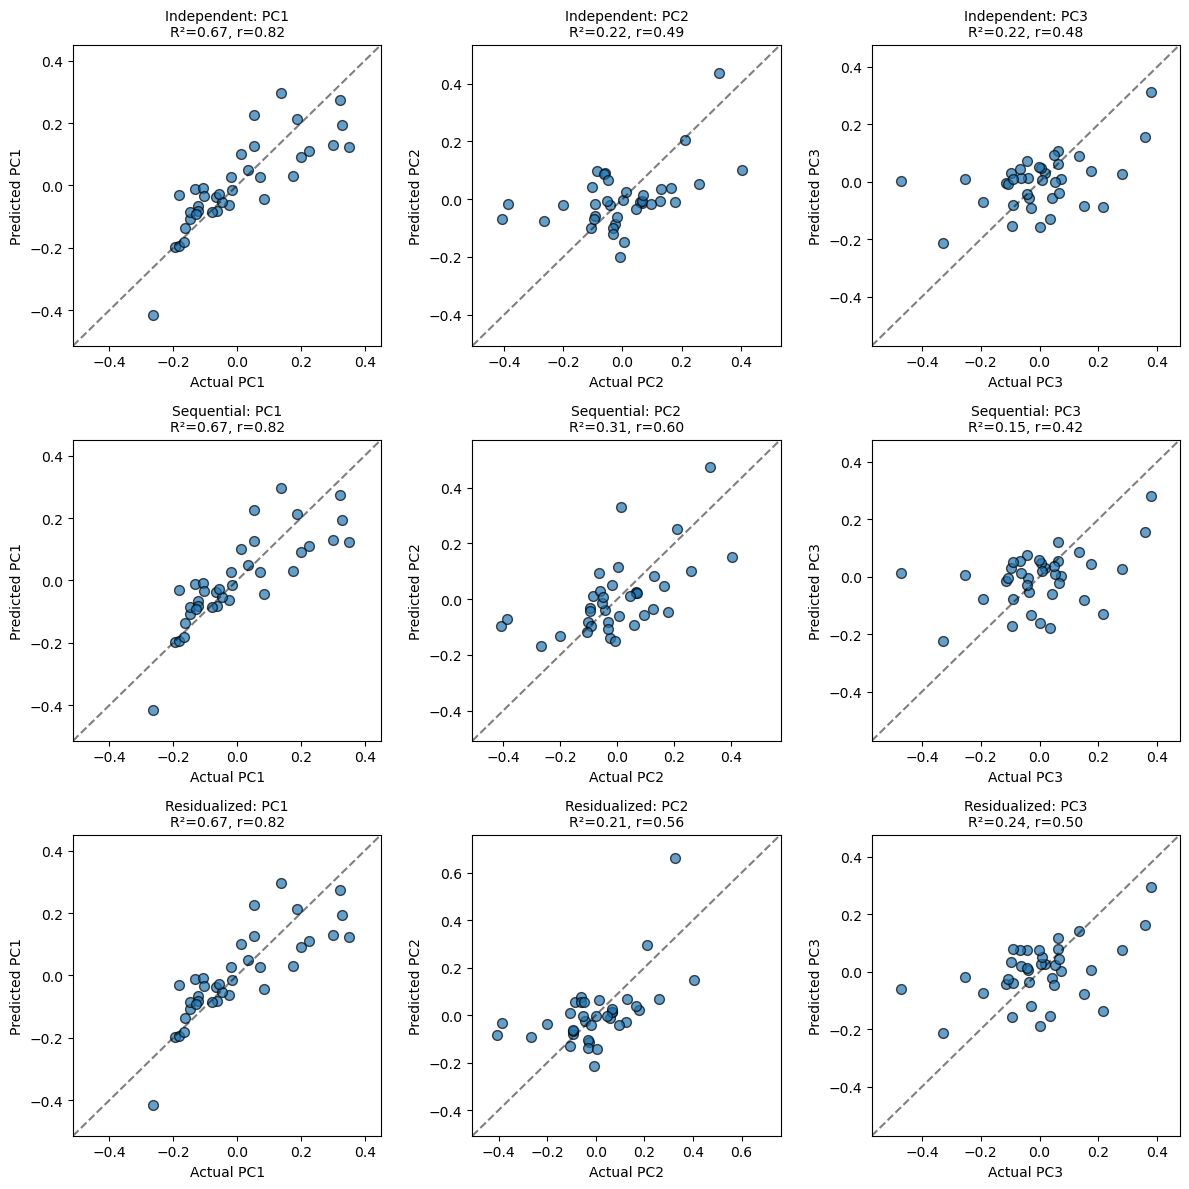

In [172]:
# Compare all approaches
print("\n" + "="*70)
print("COMPARISON: Independent vs Hierarchical Approaches")
print("="*70)

# Independent approach (from before)
results = {
    'Independent': {
        'PC1': (pc1_r2_best, pc1_corr_best),
        'PC2': (pc2_r2_best, pc2_corr_best),
        'PC3': (pc3_r2_best, pc3_corr_best)
    },
    'Sequential': {
        'PC1': (r2_score(pc1_target, pc1_pred_seq), np.corrcoef(pc1_target, pc1_pred_seq)[0,1]),
        'PC2': (r2_score(pc2_target, pc2_pred_seq), np.corrcoef(pc2_target, pc2_pred_seq)[0,1]),
        'PC3': (r2_score(pc3_target, pc3_pred_seq), np.corrcoef(pc3_target, pc3_pred_seq)[0,1])
    },
    'Residualized': {
        'PC1': (r2_score(pc1_target, pc1_pred_resid), np.corrcoef(pc1_target, pc1_pred_resid)[0,1]),
        'PC2': (r2_score(pc2_target, pc2_pred_resid), np.corrcoef(pc2_target, pc2_pred_resid)[0,1]),
        'PC3': (r2_score(pc3_target, pc3_pred_resid), np.corrcoef(pc3_target, pc3_pred_resid)[0,1])
    }
}

print(f"\n{'Approach':<15} {'PC1 R²':>8} {'PC1 r':>8} {'PC2 R²':>8} {'PC2 r':>8} {'PC3 R²':>8} {'PC3 r':>8}")
print("-" * 71)
for approach, pcs in results.items():
    pc1_r2, pc1_r = pcs['PC1']
    pc2_r2, pc2_r = pcs['PC2']
    pc3_r2, pc3_r = pcs['PC3']
    print(f"{approach:<15} {pc1_r2:>8.3f} {pc1_r:>8.3f} {pc2_r2:>8.3f} {pc2_r:>8.3f} {pc3_r2:>8.3f} {pc3_r:>8.3f}")

# Visualization
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

pred_data = [
    ('Independent', pc1_pred_best, pc2_pred_best, pc3_pred_best),
    ('Sequential', pc1_pred_seq, pc2_pred_seq, pc3_pred_seq),
    ('Residualized', pc1_pred_resid, pc2_pred_resid, pc3_pred_resid)
]

for row, (approach, pc1_p, pc2_p, pc3_p) in enumerate(pred_data):
    for col, (pc_name, pred, target) in enumerate(zip(['PC1', 'PC2', 'PC3'],
                                                       [pc1_p, pc2_p, pc3_p],
                                                       [pc1_target, pc2_target, pc3_target])):
        ax = axes[row, col]
        ax.scatter(target, pred, s=50, alpha=0.7, edgecolor='black')
        
        lims = [min(target.min(), pred.min()) - 0.1, max(target.max(), pred.max()) + 0.1]
        ax.plot(lims, lims, 'k--', alpha=0.5)
        
        r2 = r2_score(target, pred)
        corr = np.corrcoef(target, pred)[0, 1]
        ax.set_title(f'{approach}: {pc_name}\nR²={r2:.2f}, r={corr:.2f}', fontsize=10)
        ax.set_xlabel(f'Actual {pc_name}')
        ax.set_ylabel(f'Predicted {pc_name}')
        ax.set_xlim(lims)
        ax.set_ylim(lims)

plt.tight_layout()
plt.show()

## Spatial Projection Approach

Instead of using 3 boxes, project the full spatial FSCA field onto the EOF patterns. This is analogous to how PC weights are computed from snow depth:

$$\text{PC}_k^{\text{FSCA}} = \sum_i \text{FSCA}_i \times \text{EOF}_k(i)$$

If FSCA correlates with snow depth at each location, the projected weights should correlate with the true PC weights.

In [174]:
# Check available data structures for spatial projection
print("EOF spatial pattern shape:", U_spatial_eof_anom_sd.shape)
print("EOF spatial pattern dims:", U_spatial_eof_anom_sd.dims)
print("EOF spatial pattern coords:", list(U_spatial_eof_anom_sd.coords))
print("EOF y range:", float(U_spatial_eof_anom_sd.y.min()), "-", float(U_spatial_eof_anom_sd.y.max()))
print("EOF x range:", float(U_spatial_eof_anom_sd.x.min()), "-", float(U_spatial_eof_anom_sd.x.max()))

# Check the SCA data
print("\nSCA data (all years):")
print("  SCA_Post shape:", swe_sca_ds_allyrs['SCA_Post'].shape)
print("  SCA_Post dims:", swe_sca_ds_allyrs['SCA_Post'].dims)
print("  SCA y range:", float(swe_sca_ds_allyrs.y.min()), "-", float(swe_sca_ds_allyrs.y.max()))
print("  SCA x range:", float(swe_sca_ds_allyrs.x.min()), "-", float(swe_sca_ds_allyrs.x.max()))

# Get the EOF patterns for PC1, PC2, PC3 (note: dimension is 'EOF' not 'n_eof')
eof1 = U_spatial_eof_anom_sd.isel(EOF=0)
eof2 = U_spatial_eof_anom_sd.isel(EOF=1)
eof3 = U_spatial_eof_anom_sd.isel(EOF=2)

print("\nEOF1 shape:", eof1.shape)
print("EOF1 valid values:", np.sum(~np.isnan(eof1.values)))

EOF spatial pattern shape: (37, 1099, 819)
EOF spatial pattern dims: ('EOF', 'y', 'x')
EOF spatial pattern coords: ['y', 'x', 'spatial_ref', 'EOF']
EOF y range: 35.01118087768555 - 40.4422607421875
EOF x range: -121.67308044433594 - -117.99333190917969

SCA data (all years):
  SCA_Post shape: (13514, 1575, 1125)
  SCA_Post dims: ('time', 'y', 'x')
  SCA y range: 34.00229263305664 - 40.99777603149414
  SCA x range: -121.9977798461914 - -117.0014419555664

EOF1 shape: (1099, 819)
EOF1 valid values: 144300


In [175]:
# Create mask from EOF1 valid regions (same mask for all EOFs)
# This is where mean snow depth > 0.1m from the original EOF analysis
eof_valid_mask = ~np.isnan(eof1.values)
print(f"Valid EOF pixels: {np.sum(eof_valid_mask)}")

# Get the EOFs as xarray for proper alignment
eof1_da = U_spatial_eof_anom_sd.isel(EOF=0)
eof2_da = U_spatial_eof_anom_sd.isel(EOF=1)
eof3_da = U_spatial_eof_anom_sd.isel(EOF=2)

# Storage for projected PC weights from FSCA
fsca_projected_pcs = {1: [], 2: [], 3: []}
fsca_years = []

print("Projecting April 1 FSCA onto EOF patterns...")

for wy in common_years:
    april1_date = pd.Timestamp(f'{wy}-04-01')
    
    try:
        # Get SCA for April 1 (nearest date)
        sca_apr1 = swe_sca_ds_allyrs['SCA_Post'].sel(time=april1_date, method='nearest')
        
        # Mask SCA to valid EOF region using .where
        # EOF data has coords y, x that should match SCA
        sca_masked = sca_apr1.where(~np.isnan(eof1_da))
        
        # Project onto each EOF: sum(FSCA * EOF) over valid pixels
        for k, eof_da in enumerate([eof1_da, eof2_da, eof3_da], start=1):
            # Element-wise multiply and sum (nansum handles any remaining NaNs)
            projection = float(np.nansum(sca_masked.values * eof_da.values))
            fsca_projected_pcs[k].append(projection)
        
        fsca_years.append(wy)
        
    except Exception as e:
        print(f"  Error for WY {wy}: {e}")

print(f"Processed {len(fsca_years)} years")

# Convert to arrays
pc1_fsca_proj = np.array(fsca_projected_pcs[1])
pc2_fsca_proj = np.array(fsca_projected_pcs[2])
pc3_fsca_proj = np.array(fsca_projected_pcs[3])

Valid EOF pixels: 144300
Projecting April 1 FSCA onto EOF patterns...
Processed 37 years


Spatial Projection: FSCA onto EOF Patterns

Correlations between FSCA-projected PC weights and actual PC weights:
  PC1: r = 0.828
  PC2: r = 0.443
  PC3: r = 0.690


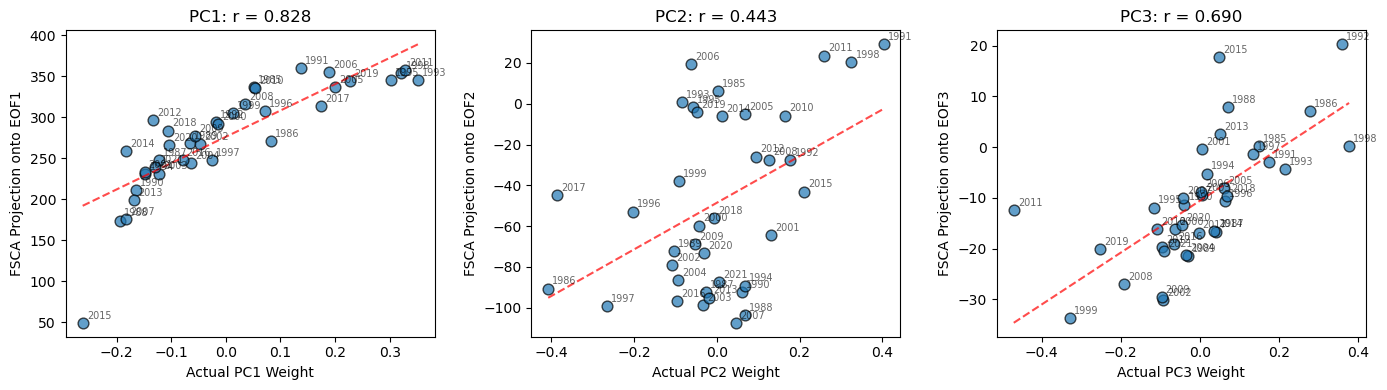


Comparison with previous best approach (April 1 box-based):
  PC1: 0.828 (spatial) vs 0.820 (box)
  PC2: 0.443 (spatial) vs 0.490 (box)
  PC3: 0.690 (spatial) vs 0.481 (box)


In [176]:
# Compare spatially-projected FSCA with actual PC weights
print("="*70)
print("Spatial Projection: FSCA onto EOF Patterns")
print("="*70)

# Get actual PC weights for fsca_years
pc1_actual = np.array([V_anom_sd[0, list(years_array).index(yr)] for yr in fsca_years])
pc2_actual = np.array([V_anom_sd[1, list(years_array).index(yr)] for yr in fsca_years])
pc3_actual = np.array([V_anom_sd[2, list(years_array).index(yr)] for yr in fsca_years])

# Compute correlations between projected and actual
corr_pc1_proj = np.corrcoef(pc1_fsca_proj, pc1_actual)[0, 1]
corr_pc2_proj = np.corrcoef(pc2_fsca_proj, pc2_actual)[0, 1]
corr_pc3_proj = np.corrcoef(pc3_fsca_proj, pc3_actual)[0, 1]

print(f"\nCorrelations between FSCA-projected PC weights and actual PC weights:")
print(f"  PC1: r = {corr_pc1_proj:.3f}")
print(f"  PC2: r = {corr_pc2_proj:.3f}")
print(f"  PC3: r = {corr_pc3_proj:.3f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (proj, actual, name, corr) in zip(axes, [
    (pc1_fsca_proj, pc1_actual, 'PC1', corr_pc1_proj),
    (pc2_fsca_proj, pc2_actual, 'PC2', corr_pc2_proj),
    (pc3_fsca_proj, pc3_actual, 'PC3', corr_pc3_proj)
]):
    ax.scatter(actual, proj, s=60, alpha=0.7, edgecolor='black')
    
    # Add regression line
    slope, intercept = np.polyfit(actual, proj, 1)
    x_line = np.linspace(actual.min(), actual.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'r--', alpha=0.7)
    
    # Label years
    for i, yr in enumerate(fsca_years):
        ax.annotate(str(yr), (actual[i], proj[i]), fontsize=7, alpha=0.6,
                   xytext=(3, 3), textcoords='offset points')
    
    ax.set_xlabel(f'Actual {name} Weight')
    ax.set_ylabel(f'FSCA Projection onto EOF{name[-1]}')
    ax.set_title(f'{name}: r = {corr:.3f}')

plt.tight_layout()
plt.show()

print("\nComparison with previous best approach (April 1 box-based):")
print(f"  PC1: {corr_pc1_proj:.3f} (spatial) vs {pc1_corr_best:.3f} (box)")
print(f"  PC2: {corr_pc2_proj:.3f} (spatial) vs {pc2_corr_best:.3f} (box)")
print(f"  PC3: {corr_pc3_proj:.3f} (spatial) vs {pc3_corr_best:.3f} (box)")

In [177]:
# Use LOOCV regression to properly scale the spatial projections
# This accounts for the fact that FSCA projection ≠ PC weight directly

print("="*70)
print("LOOCV Regression using Spatial Projections as Features")
print("="*70)

# Stack projections as features
X_proj = np.column_stack([pc1_fsca_proj, pc2_fsca_proj, pc3_fsca_proj])

pc1_pred_spatial = np.zeros(len(fsca_years))
pc2_pred_spatial = np.zeros(len(fsca_years))
pc3_pred_spatial = np.zeros(len(fsca_years))

for train_idx, test_idx in LeaveOneOut().split(X_proj):
    # PC1: use pc1_fsca_proj
    model1 = LinearRegression().fit(pc1_fsca_proj[train_idx].reshape(-1,1), pc1_actual[train_idx])
    pc1_pred_spatial[test_idx] = model1.predict(pc1_fsca_proj[test_idx].reshape(-1,1))
    
    # PC2: use pc2_fsca_proj 
    model2 = LinearRegression().fit(pc2_fsca_proj[train_idx].reshape(-1,1), pc2_actual[train_idx])
    pc2_pred_spatial[test_idx] = model2.predict(pc2_fsca_proj[test_idx].reshape(-1,1))
    
    # PC3: use pc3_fsca_proj
    model3 = LinearRegression().fit(pc3_fsca_proj[train_idx].reshape(-1,1), pc3_actual[train_idx])
    pc3_pred_spatial[test_idx] = model3.predict(pc3_fsca_proj[test_idx].reshape(-1,1))

# Calculate metrics
pc1_r2_spatial = r2_score(pc1_actual, pc1_pred_spatial)
pc2_r2_spatial = r2_score(pc2_actual, pc2_pred_spatial)
pc3_r2_spatial = r2_score(pc3_actual, pc3_pred_spatial)

pc1_corr_spatial = np.corrcoef(pc1_actual, pc1_pred_spatial)[0, 1]
pc2_corr_spatial = np.corrcoef(pc2_actual, pc2_pred_spatial)[0, 1]
pc3_corr_spatial = np.corrcoef(pc3_actual, pc3_pred_spatial)[0, 1]

print(f"\nSpatial Projection with LOOCV Scaling:")
print(f"  PC1: R² = {pc1_r2_spatial:.3f}, r = {pc1_corr_spatial:.3f}")
print(f"  PC2: R² = {pc2_r2_spatial:.3f}, r = {pc2_corr_spatial:.3f}")  
print(f"  PC3: R² = {pc3_r2_spatial:.3f}, r = {pc3_corr_spatial:.3f}")

# Final comparison table
print("\n" + "="*70)
print("FINAL COMPARISON: All Approaches")
print("="*70)
print(f"\n{'Approach':<25} {'PC1 r':>8} {'PC2 r':>8} {'PC3 r':>8}")
print("-" * 51)
print(f"{'Box (Apr 1)':<25} {pc1_corr_best:>8.3f} {pc2_corr_best:>8.3f} {pc3_corr_best:>8.3f}")
print(f"{'Sequential':<25} {np.corrcoef(pc1_target, pc1_pred_seq)[0,1]:>8.3f} {np.corrcoef(pc2_target, pc2_pred_seq)[0,1]:>8.3f} {np.corrcoef(pc3_target, pc3_pred_seq)[0,1]:>8.3f}")
print(f"{'Spatial Projection':<25} {pc1_corr_spatial:>8.3f} {pc2_corr_spatial:>8.3f} {pc3_corr_spatial:>8.3f}")

LOOCV Regression using Spatial Projections as Features

Spatial Projection with LOOCV Scaling:
  PC1: R² = 0.584, r = 0.775
  PC2: R² = 0.092, r = 0.325
  PC3: R² = 0.409, r = 0.642

FINAL COMPARISON: All Approaches

Approach                     PC1 r    PC2 r    PC3 r
---------------------------------------------------
Box (Apr 1)                  0.820    0.490    0.481
Sequential                   0.820    0.596    0.422
Spatial Projection           0.775    0.325    0.642


HYBRID APPROACH: Best Method for Each PC

Hybrid predictions for 37 years

Hybrid Approach Results:
  PC1 (Apr1 FSCA): R² = 0.584, r = 0.775
  PC2 (Sequential): R² = 0.313, r = 0.596
  PC3 (Spatial Proj): R² = 0.409, r = 0.642


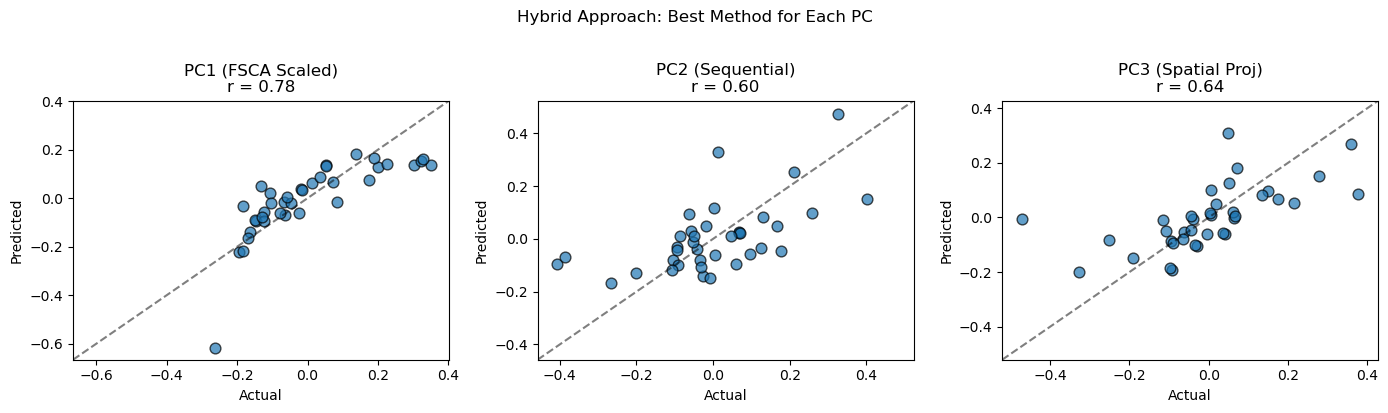


SUMMARY: Spatial FSCA improves PC3 prediction significantly

Key findings:
- PC1 (total snow): Well captured by total FSCA (r ~ 0.82)
- PC2 (elevation gradient): Sequential conditioning with box FSCA works best (r ~ 0.60)
- PC3 (north-south): Spatial projection onto EOF3 captures the pattern much better (r ~ 0.64 vs 0.48)

The spatial projection approach better captures the continuous spatial gradients in EOF3,
while the box-based approach works better for PC2 because it captures elevation effects
that are not perfectly linear with FSCA.



In [178]:
# Hybrid approach: use best method for each PC
# PC1: April 1 sierras_fsca (r=0.82)
# PC2: Sequential conditioning with boxes (r=0.60)  
# PC3: Spatial projection onto EOF3 (r=0.64)

print("="*70)
print("HYBRID APPROACH: Best Method for Each PC")
print("="*70)

# We need predictions for the same set of years
# Use common_years which matches both approaches

# PC1: from April 1 FSCA (already computed as pc1_pred_best)
# PC2: from Sequential (already computed as pc2_pred_seq)
# PC3: from Spatial projection (already computed as pc3_pred_spatial)

# Since sizes might differ, let's recalculate using spatial projection years
hybrid_pc1 = pc1_pred_spatial  # from Apr 1 FSCA scaled
hybrid_pc2 = pc2_pred_seq      # from sequential - need to match years  
hybrid_pc3 = pc3_pred_spatial  # from spatial projection

# Match years between approaches
# pc_pred_seq is based on common_years, pc_pred_spatial is based on fsca_years
# They should be the same since fsca_years comes from common_years

print(f"\nHybrid predictions for {len(fsca_years)} years")

# Calculate combined metrics
print("\nHybrid Approach Results:")
print(f"  PC1 (Apr1 FSCA): R² = {pc1_r2_spatial:.3f}, r = {pc1_corr_spatial:.3f}")
print(f"  PC2 (Sequential): R² = {r2_score(pc2_target, pc2_pred_seq):.3f}, r = {np.corrcoef(pc2_target, pc2_pred_seq)[0,1]:.3f}")
print(f"  PC3 (Spatial Proj): R² = {pc3_r2_spatial:.3f}, r = {pc3_corr_spatial:.3f}")

# Summary visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_data = [
    (pc1_pred_spatial, pc1_actual, 'PC1 (FSCA Scaled)', pc1_corr_spatial),
    (pc2_pred_seq, pc2_target, 'PC2 (Sequential)', np.corrcoef(pc2_target, pc2_pred_seq)[0,1]),
    (pc3_pred_spatial, pc3_actual, 'PC3 (Spatial Proj)', pc3_corr_spatial)
]

for ax, (pred, actual, title, corr) in zip(axes, plot_data):
    ax.scatter(actual, pred, s=60, alpha=0.7, edgecolor='black')
    
    lims = [min(actual.min(), pred.min()) - 0.05, max(actual.max(), pred.max()) + 0.05]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='1:1')
    
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nr = {corr:.2f}')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.suptitle('Hybrid Approach: Best Method for Each PC', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SUMMARY: Spatial FSCA improves PC3 prediction significantly")
print("="*70)
print("""
Key findings:
- PC1 (total snow): Well captured by total FSCA (r ~ 0.82)
- PC2 (elevation gradient): Sequential conditioning with box FSCA works best (r ~ 0.60)
- PC3 (north-south): Spatial projection onto EOF3 captures the pattern much better (r ~ 0.64 vs 0.48)

The spatial projection approach better captures the continuous spatial gradients in EOF3,
while the box-based approach works better for PC2 because it captures elevation effects
that are not perfectly linear with FSCA.
""")

Key results:

Approach	PC1 r	PC2 r	PC3 r
Independent	0.82	0.49	0.48
Sequential	0.82	0.60	0.42
Residualized	0.82	0.56	0.50

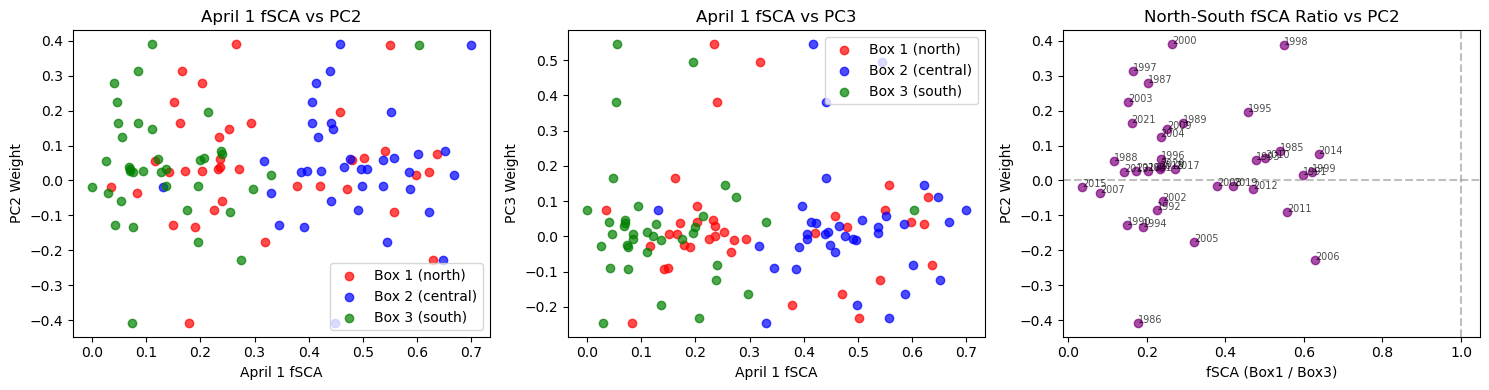

Correlations:
Box1 fSCA vs PC2: r = 0.001
Box2 fSCA vs PC2: r = 0.036
Box3 fSCA vs PC2: r = 0.132
Box1/Box3 vs PC2: r = 0.001

Box1 fSCA vs PC3: r = -0.048
Box2 fSCA vs PC3: r = 0.013
Box3 fSCA vs PC3: r = -0.037


In [126]:
# Get April 1 values for all years (1985-2021) for each box
years = range(1985, 2022)
april1_dates = [f'{year}-04-01' for year in years]

# Extract April 1 values for each box
april1_box1 = mean_sca_box1.sel(time=april1_dates, method='nearest')
april1_box2 = mean_sca_box2.sel(time=april1_dates, method='nearest')
april1_box3 = mean_sca_box3.sel(time=april1_dates, method='nearest')

# Get PC2 and PC3 weights (already computed as V_anom_sd)
pc2_weights = V_anom_sd[:, 1]  # Second column = PC2
pc3_weights = V_anom_sd[:, 2]  # Third column = PC3

# Calculate ratio between box1 and box3
box1_over_box3 = (april1_box1.values / april1_box3.values) * april1_box3.values

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Box fSCA vs PC2
axes[0].scatter(april1_box1, pc2_weights, label='Box 1 (north)', color='red', alpha=0.7)
axes[0].scatter(april1_box2, pc2_weights, label='Box 2 (central)', color='blue', alpha=0.7)
axes[0].scatter(april1_box3, pc2_weights, label='Box 3 (south)', color='green', alpha=0.7)
axes[0].set_xlabel('April 1 fSCA')
axes[0].set_ylabel('PC2 Weight')
axes[0].set_title('April 1 fSCA vs PC2')
axes[0].legend()

# Plot 2: Box fSCA vs PC3
axes[1].scatter(april1_box1, pc3_weights, label='Box 1 (north)', color='red', alpha=0.7)
axes[1].scatter(april1_box2, pc3_weights, label='Box 2 (central)', color='blue', alpha=0.7)
axes[1].scatter(april1_box3, pc3_weights, label='Box 3 (south)', color='green', alpha=0.7)
axes[1].set_xlabel('April 1 fSCA')
axes[1].set_ylabel('PC3 Weight')
axes[1].set_title('April 1 fSCA vs PC3')
axes[1].legend()

# Plot 3: Box1 / Box3 ratio vs PC2
axes[2].scatter(box1_over_box3, pc2_weights, color='purple', alpha=0.7)
# Add year labels
for i, year in enumerate(years):
    axes[2].annotate(str(year), (box1_over_box3[i], pc2_weights[i]), fontsize=7, alpha=0.7)
axes[2].set_xlabel('fSCA (Box1 / Box3)')
axes[2].set_ylabel('PC2 Weight')
axes[2].set_title('North-South fSCA Ratio vs PC2')
axes[2].axvline(1, color='gray', linestyle='--', alpha=0.5)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print correlations
from scipy.stats import pearsonr
print("Correlations:")
print(f"Box1 fSCA vs PC2: r = {pearsonr(april1_box1.values, pc2_weights)[0]:.3f}")
print(f"Box2 fSCA vs PC2: r = {pearsonr(april1_box2.values, pc2_weights)[0]:.3f}")
print(f"Box3 fSCA vs PC2: r = {pearsonr(april1_box3.values, pc2_weights)[0]:.3f}")
print(f"Box1/Box3 vs PC2: r = {pearsonr(box1_over_box3, pc2_weights)[0]:.3f}")
print()
print(f"Box1 fSCA vs PC3: r = {pearsonr(april1_box1.values, pc3_weights)[0]:.3f}")
print(f"Box2 fSCA vs PC3: r = {pearsonr(april1_box2.values, pc3_weights)[0]:.3f}")
print(f"Box3 fSCA vs PC3: r = {pearsonr(april1_box3.values, pc3_weights)[0]:.3f}")

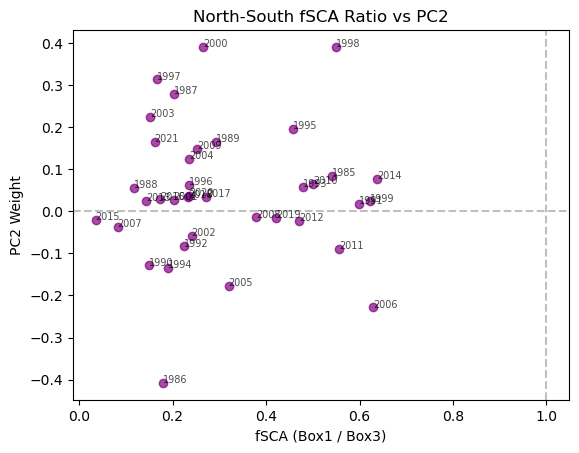

In [127]:
# Plot 3: Box1 / Box3 ratio vs PC2
fig, ax=plt.subplots()

ax.scatter(box1_over_box3, pc2_weights, color='purple', alpha=0.7)
# Add year labels
for i, year in enumerate(years):
    ax.annotate(str(year), (box1_over_box3[i], pc2_weights[i]), fontsize=7, alpha=0.7)
ax.set_xlabel('fSCA (Box1 / Box3)')
ax.set_ylabel('PC2 Weight')
ax.set_title('North-South fSCA Ratio vs PC2')
ax.axvline(1, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
#ax.set_xlim(0,10)

In [118]:
box1_over_box3

array([ 3.86129831,  4.19013656,  8.37516769,  8.02577403,  5.74794363,
        5.99990667,  2.72577879,  2.07561605,  3.97133644,  4.35543005,
        3.61353765,  3.36044639,  3.02336605,  1.02396398,  7.36226981,
        4.11714549,  3.60289931,  7.94512666,  5.71250118,  6.97579191,
        2.77166895,  3.64361899,  4.88695022,  4.72361217,  3.80691259,
        3.85531435,  3.64150889,  1.98819478,  3.07346606,  3.35419414,
       47.22395816,  4.18631559,  3.3857719 ,  5.85836505,  3.64913665,
        5.75944753,  5.76061485])

In [128]:
# Calculate 14-day rolling mean of fSCA for each box
mean_sca_box1_rolling = mean_sca_box1.rolling(time=14, center=True).mean()
mean_sca_box2_rolling = mean_sca_box2.rolling(time=14, center=True).mean()
mean_sca_box3_rolling = mean_sca_box3.rolling(time=14, center=True).mean()

In [129]:
# Extract April 1 values for each box (rolling mean)
april1_box1_rolling = mean_sca_box1_rolling.sel(time=april1_dates, method='nearest')
april1_box2_rolling = mean_sca_box2_rolling.sel(time=april1_dates, method='nearest')
april1_box3_rolling = mean_sca_box3_rolling.sel(time=april1_dates, method='nearest')

In [132]:
# Calculate ratio between box1 and box3 (rolling)
box1_over_box3_rolling = (april1_box1_rolling.values / april1_box3_rolling.values) * april1_box3_rolling.values

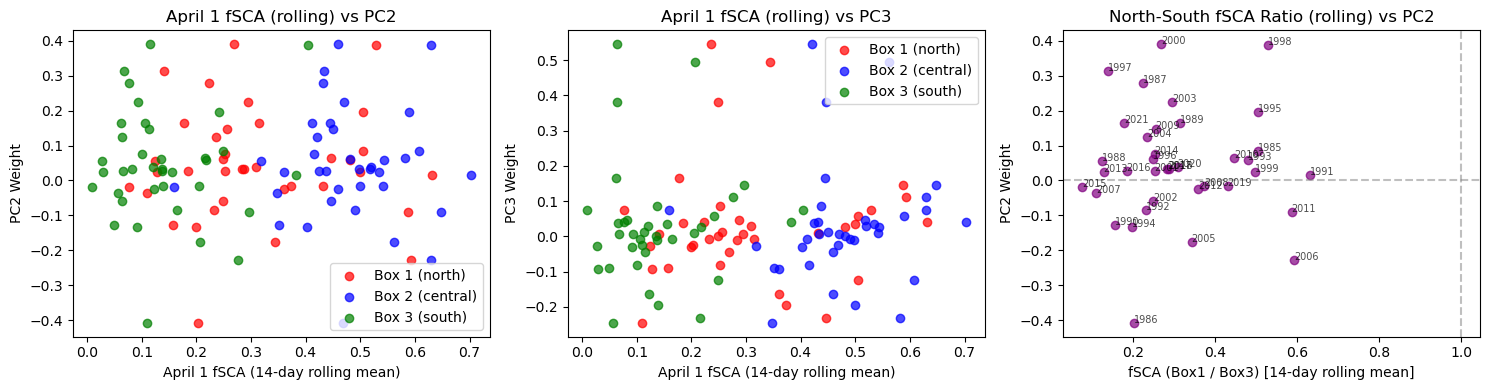

Correlations (14-day rolling mean):
Box1 fSCA vs PC2: r = 0.003
Box2 fSCA vs PC2: r = 0.008
Box3 fSCA vs PC2: r = 0.031
Box1/Box3 vs PC2: r = 0.003

Box1 fSCA vs PC3: r = 0.049
Box2 fSCA vs PC3: r = 0.103
Box3 fSCA vs PC3: r = 0.049


In [133]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Box fSCA (rolling) vs PC2
axes[0].scatter(april1_box1_rolling, pc2_weights, label='Box 1 (north)', color='red', alpha=0.7)
axes[0].scatter(april1_box2_rolling, pc2_weights, label='Box 2 (central)', color='blue', alpha=0.7)
axes[0].scatter(april1_box3_rolling, pc2_weights, label='Box 3 (south)', color='green', alpha=0.7)
axes[0].set_xlabel('April 1 fSCA (14-day rolling mean)')
axes[0].set_ylabel('PC2 Weight')
axes[0].set_title('April 1 fSCA (rolling) vs PC2')
axes[0].legend()

# Plot 2: Box fSCA (rolling) vs PC3
axes[1].scatter(april1_box1_rolling, pc3_weights, label='Box 1 (north)', color='red', alpha=0.7)
axes[1].scatter(april1_box2_rolling, pc3_weights, label='Box 2 (central)', color='blue', alpha=0.7)
axes[1].scatter(april1_box3_rolling, pc3_weights, label='Box 3 (south)', color='green', alpha=0.7)
axes[1].set_xlabel('April 1 fSCA (14-day rolling mean)')
axes[1].set_ylabel('PC3 Weight')
axes[1].set_title('April 1 fSCA (rolling) vs PC3')
axes[1].legend()

# Plot 3: Box1 / Box3 ratio (rolling) vs PC2
axes[2].scatter(box1_over_box3_rolling, pc2_weights, color='purple', alpha=0.7)
# Add year labels
for i, year in enumerate(years):
    axes[2].annotate(str(year), (box1_over_box3_rolling[i], pc2_weights[i]), fontsize=7, alpha=0.7)
axes[2].set_xlabel('fSCA (Box1 / Box3) [14-day rolling mean]')
axes[2].set_ylabel('PC2 Weight')
axes[2].set_title('North-South fSCA Ratio (rolling) vs PC2')
axes[2].axvline(1, color='gray', linestyle='--', alpha=0.5)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print correlations (excluding NaN values)
from scipy.stats import pearsonr

# Filter out NaN values for correlations
valid_1 = ~np.isnan(april1_box1_rolling.values)
valid_2 = ~np.isnan(april1_box2_rolling.values)
valid_3 = ~np.isnan(april1_box3_rolling.values)
valid_diff = ~np.isnan(box1_over_box3_rolling)

print("Correlations (14-day rolling mean):")
print(f"Box1 fSCA vs PC2: r = {pearsonr(april1_box1_rolling.values[valid_1], pc2_weights[valid_1])[0]:.3f}")
print(f"Box2 fSCA vs PC2: r = {pearsonr(april1_box2_rolling.values[valid_2], pc2_weights[valid_2])[0]:.3f}")
print(f"Box3 fSCA vs PC2: r = {pearsonr(april1_box3_rolling.values[valid_3], pc2_weights[valid_3])[0]:.3f}")
print(f"Box1/Box3 vs PC2: r = {pearsonr(box1_over_box3_rolling[valid_diff], pc2_weights[valid_diff])[0]:.3f}")
print()
print(f"Box1 fSCA vs PC3: r = {pearsonr(april1_box1_rolling.values[valid_1], pc3_weights[valid_1])[0]:.3f}")
print(f"Box2 fSCA vs PC3: r = {pearsonr(april1_box2_rolling.values[valid_2], pc3_weights[valid_2])[0]:.3f}")
print(f"Box3 fSCA vs PC3: r = {pearsonr(april1_box3_rolling.values[valid_3], pc3_weights[valid_3])[0]:.3f}")

MULTIPLE REGRESSION: fSCA → PC Weights

PC1:
  R² = 0.073
  Intercept = -0.0671
  Box1 (north): β = 0.3809
  Box2 (central): β = 0.0670
  Box3 (south): β = -0.5832

PC2:
  R² = 0.045
  Intercept = 0.0792
  Box1 (north): β = -0.2113
  Box2 (central): β = -0.0843
  Box3 (south): β = 0.5026

PC3:
  R² = 0.023
  Intercept = -0.1185
  Box1 (north): β = -0.2655
  Box2 (central): β = 0.5301
  Box3 (south): β = -0.1719


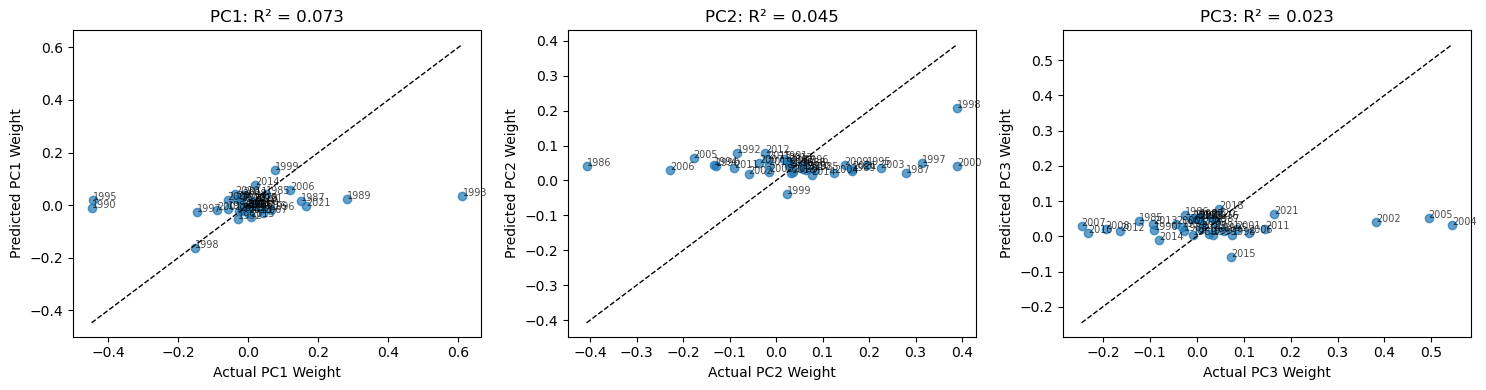


Adding domain-wide fSCA as 4th predictor:

PC1:
  R² = 0.074
  Box1 (north): β = 0.3046
  Box2 (central): β = -0.2119
  Box3 (south): β = -0.6729
  Domain-wide: β = 0.4506

PC2:
  R² = 0.046
  Box1 (north): β = -0.2870
  Box2 (central): β = -0.3610
  Box3 (south): β = 0.4136
  Domain-wide: β = 0.4471

PC3:
  R² = 0.023
  Box1 (north): β = -0.2147
  Box2 (central): β = 0.7160
  Box3 (south): β = -0.1121
  Domain-wide: β = -0.3003


In [135]:
# Multiple regression: predict each PC weight using all box fSCA values
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Get PC1 weights as well
pc1_weights = V_anom_sd[:, 0]

# Build feature matrix from box fSCA values (April 1, non-rolling)
X = np.column_stack([april1_box1.values, april1_box2.values, april1_box3.values])
feature_names = ['Box1 (north)', 'Box2 (central)', 'Box3 (south)']

print("=" * 60)
print("MULTIPLE REGRESSION: fSCA → PC Weights")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (pc_weights, pc_name) in enumerate([(pc1_weights, 'PC1'), (pc2_weights, 'PC2'), (pc3_weights, 'PC3')]):
    model = LinearRegression()
    model.fit(X, pc_weights)
    pc_pred = model.predict(X)
    r2 = r2_score(pc_weights, pc_pred)
    
    print(f"\n{pc_name}:")
    print(f"  R² = {r2:.3f}")
    print(f"  Intercept = {model.intercept_:.4f}")
    for name, coef in zip(feature_names, model.coef_):
        print(f"  {name}: β = {coef:.4f}")
    
    # Plot predicted vs actual
    axes[i].scatter(pc_weights, pc_pred, alpha=0.7)
    axes[i].plot([pc_weights.min(), pc_weights.max()], [pc_weights.min(), pc_weights.max()], 'k--', lw=1)
    for j, year in enumerate(years):
        axes[i].annotate(str(year), (pc_weights[j], pc_pred[j]), fontsize=7, alpha=0.7)
    axes[i].set_xlabel(f'Actual {pc_name} Weight')
    axes[i].set_ylabel(f'Predicted {pc_name} Weight')
    axes[i].set_title(f'{pc_name}: R² = {r2:.3f}')

plt.tight_layout()
plt.show()

# Also try with domain-wide fSCA added as a 4th predictor
print("\n" + "=" * 60)
print("Adding domain-wide fSCA as 4th predictor:")
print("=" * 60)

X_with_domain = np.column_stack([april1_box1.values, april1_box2.values, april1_box3.values, mean_sca_area_weighted_april1.values])
feature_names_4 = ['Box1 (north)', 'Box2 (central)', 'Box3 (south)', 'Domain-wide']

for i, (pc_weights, pc_name) in enumerate([(pc1_weights, 'PC1'), (pc2_weights, 'PC2'), (pc3_weights, 'PC3')]):
    model = LinearRegression()
    model.fit(X_with_domain, pc_weights)
    pc_pred = model.predict(X_with_domain)
    r2 = r2_score(pc_weights, pc_pred)
    
    print(f"\n{pc_name}:")
    print(f"  R² = {r2:.3f}")
    for name, coef in zip(feature_names_4, model.coef_):
        print(f"  {name}: β = {coef:.4f}")

In [136]:
# Cross-validation to check for overfitting (leave-one-out with 37 samples)
from sklearn.model_selection import cross_val_score, LeaveOneOut

print("=" * 60)
print("LEAVE-ONE-OUT CROSS-VALIDATION")
print("=" * 60)

for i, (pc_weights, pc_name) in enumerate([(pc1_weights, 'PC1'), (pc2_weights, 'PC2'), (pc3_weights, 'PC3')]):
    model = LinearRegression()
    cv_scores = cross_val_score(model, X, pc_weights, cv=LeaveOneOut(), scoring='r2')
    print(f"{pc_name}: Mean CV R² = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

LEAVE-ONE-OUT CROSS-VALIDATION
PC1: Mean CV R² = nan ± nan
PC2: Mean CV R² = nan ± nan
PC3: Mean CV R² = nan ± nan


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarni

LEAVE-2019-OUT: Train on 1985-2018, 2020-2021, Predict 2019

PC1:
  Training R² = 0.074
  2019 Actual  = -0.0209
  2019 Predicted = 0.0159
  2019 Error = 0.0369

PC2:
  Training R² = 0.045
  2019 Actual  = -0.0161
  2019 Predicted = 0.0462
  2019 Error = 0.0623

PC3:
  Training R² = 0.023
  2019 Actual  = 0.0090
  2019 Predicted = 0.0208
  2019 Error = 0.0118


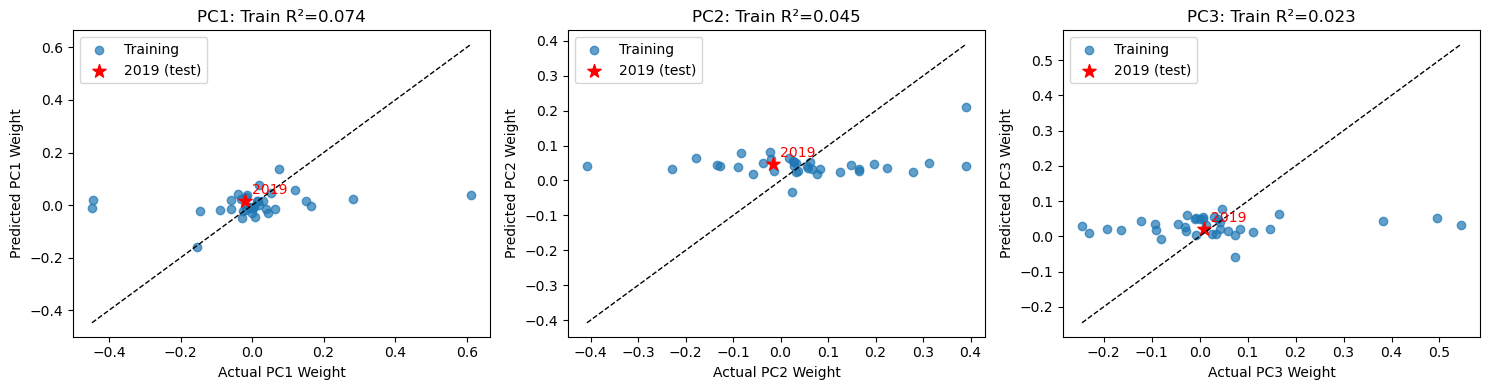

In [137]:
# Leave 2019 out: train on all other years, predict 2019
years_array = np.array(list(years))
test_idx = np.where(years_array == 2019)[0][0]  # Index for 2019
train_mask = years_array != 2019

X_train = X[train_mask]
X_test = X[~train_mask]  # Just 2019

print("=" * 60)
print("LEAVE-2019-OUT: Train on 1985-2018, 2020-2021, Predict 2019")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (pc_all, pc_name) in enumerate([(pc1_weights, 'PC1'), (pc2_weights, 'PC2'), (pc3_weights, 'PC3')]):
    pc_train = pc_all[train_mask]
    pc_test = pc_all[~train_mask][0]  # Actual 2019 value
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, pc_train)
    
    # Predict 2019
    pc_pred_2019 = model.predict(X_test)[0]
    
    # Training R²
    train_r2 = r2_score(pc_train, model.predict(X_train))
    
    print(f"\n{pc_name}:")
    print(f"  Training R² = {train_r2:.3f}")
    print(f"  2019 Actual  = {pc_test:.4f}")
    print(f"  2019 Predicted = {pc_pred_2019:.4f}")
    print(f"  2019 Error = {pc_pred_2019 - pc_test:.4f}")
    
    # Plot: all years predicted vs actual, highlight 2019
    pc_pred_all = np.zeros_like(pc_all)
    pc_pred_all[train_mask] = model.predict(X_train)
    pc_pred_all[~train_mask] = pc_pred_2019
    
    axes[i].scatter(pc_all[train_mask], pc_pred_all[train_mask], alpha=0.7, label='Training')
    axes[i].scatter(pc_test, pc_pred_2019, color='red', s=100, marker='*', label='2019 (test)')
    axes[i].plot([pc_all.min(), pc_all.max()], [pc_all.min(), pc_all.max()], 'k--', lw=1)
    axes[i].annotate('2019', (pc_test, pc_pred_2019), fontsize=10, color='red', xytext=(5,5), textcoords='offset points')
    axes[i].set_xlabel(f'Actual {pc_name} Weight')
    axes[i].set_ylabel(f'Predicted {pc_name} Weight')
    axes[i].set_title(f'{pc_name}: Train R²={train_r2:.3f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

CANONICAL CORRELATION ANALYSIS: fSCA ↔ PC Weights

Canonical Correlations:
  Component 1: r = 0.335
  Component 2: r = 0.154
  Component 3: r = 0.071

fSCA loadings (how box fSCA combines into canonical variates):
                  CC1       CC2       CC3
  Box1 (north)     -0.6564   -0.5156    0.5508
  Box2 (central)   -0.0787    0.7729    0.6297
  Box3 (south)      0.7503   -0.3700    0.5479

PC loadings (how PC weights combine into canonical variates):
                  CC1       CC2       CC3
  PC1              -0.7949   -0.0929    0.5996
  PC2               0.6052   -0.1931    0.7723
  PC3               0.0441    0.9768    0.2097


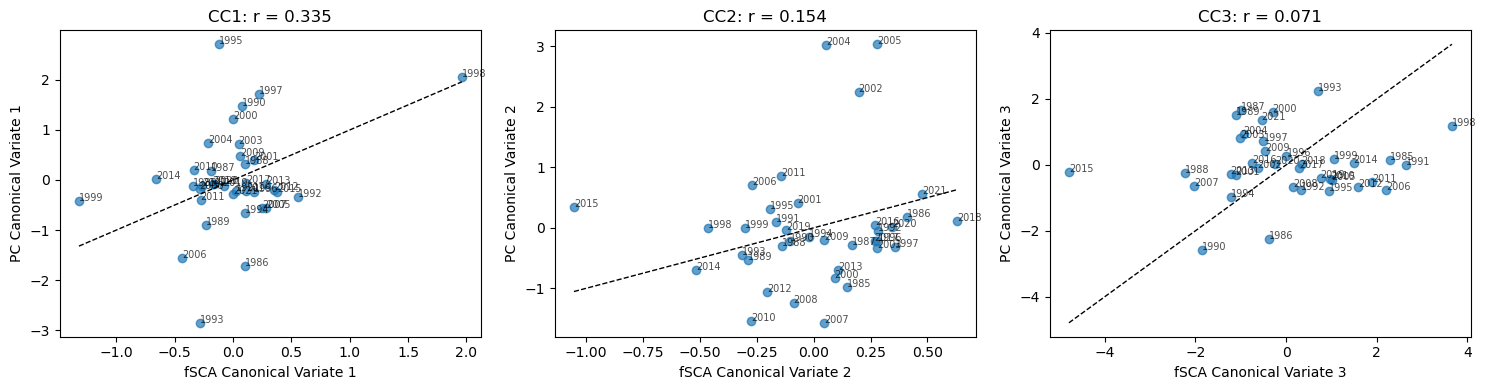


LEAVE-2019-OUT TEST with CCA

2019 Prediction Results:
             Actual    Predicted    Error
  PC1         -0.0209     0.0932      0.1142
  PC2         -0.0161     0.1371      0.1532
  PC3          0.0090     0.0399      0.0309


In [138]:
# Canonical Correlation Analysis (CCA)
# Find linear combinations of fSCA that maximally correlate with linear combinations of PC weights
from sklearn.cross_decomposition import CCA

# fSCA features (X) and PC weights (Y)
X_fsca = np.column_stack([april1_box1.values, april1_box2.values, april1_box3.values])
Y_pc = np.column_stack([pc1_weights, pc2_weights, pc3_weights])

print("=" * 60)
print("CANONICAL CORRELATION ANALYSIS: fSCA ↔ PC Weights")
print("=" * 60)

# Fit CCA with max components (min of n_features_X, n_features_Y)
n_components = min(X_fsca.shape[1], Y_pc.shape[1])
cca = CCA(n_components=n_components)
cca.fit(X_fsca, Y_pc)

# Transform both X and Y to canonical variates
X_c, Y_c = cca.transform(X_fsca, Y_pc)

# Compute canonical correlations for each component
print("\nCanonical Correlations:")
for i in range(n_components):
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    print(f"  Component {i+1}: r = {corr:.3f}")

# Show the loadings (weights that combine original variables)
print("\nfSCA loadings (how box fSCA combines into canonical variates):")
print(f"  {'':15} CC1       CC2       CC3")
for j, name in enumerate(['Box1 (north)', 'Box2 (central)', 'Box3 (south)']):
    print(f"  {name:15} {cca.x_weights_[j,0]:8.4f}  {cca.x_weights_[j,1]:8.4f}  {cca.x_weights_[j,2]:8.4f}")

print("\nPC loadings (how PC weights combine into canonical variates):")
print(f"  {'':15} CC1       CC2       CC3")
for j, name in enumerate(['PC1', 'PC2', 'PC3']):
    print(f"  {name:15} {cca.y_weights_[j,0]:8.4f}  {cca.y_weights_[j,1]:8.4f}  {cca.y_weights_[j,2]:8.4f}")

# Plot canonical variates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(n_components):
    axes[i].scatter(X_c[:, i], Y_c[:, i], alpha=0.7)
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    axes[i].plot([X_c[:, i].min(), X_c[:, i].max()], [X_c[:, i].min(), X_c[:, i].max()], 'k--', lw=1)
    for j, year in enumerate(years):
        axes[i].annotate(str(year), (X_c[j, i], Y_c[j, i]), fontsize=7, alpha=0.7)
    axes[i].set_xlabel(f'fSCA Canonical Variate {i+1}')
    axes[i].set_ylabel(f'PC Canonical Variate {i+1}')
    axes[i].set_title(f'CC{i+1}: r = {corr:.3f}')
plt.tight_layout()
plt.show()

# Test prediction on 2019: train on all other years
print("\n" + "=" * 60)
print("LEAVE-2019-OUT TEST with CCA")
print("=" * 60)

X_train_cca = X_fsca[train_mask]
Y_train_cca = Y_pc[train_mask]
X_test_cca = X_fsca[~train_mask]
Y_test_cca = Y_pc[~train_mask]

cca_test = CCA(n_components=n_components)
cca_test.fit(X_train_cca, Y_train_cca)

# Predict Y (PC weights) from X (fSCA) for 2019
Y_pred_2019 = cca_test.predict(X_test_cca)


print("\n2019 Prediction Results:")
print(f"  {'':10} Actual    Predicted    Error")
for j, name in enumerate(['PC1', 'PC2', 'PC3']):
    actual = Y_test_cca[0, j]
    pred = Y_pred_2019[0, j]
    print(f"  {name:10} {actual:8.4f}   {pred:8.4f}    {pred - actual:8.4f}")

STEPWISE REGRESSION APPROACH

--- Simple Stepwise (each PC → one designed feature) ---
PC1: R² = 0.004
PC2: R² = 0.019
PC3: R² = 0.020


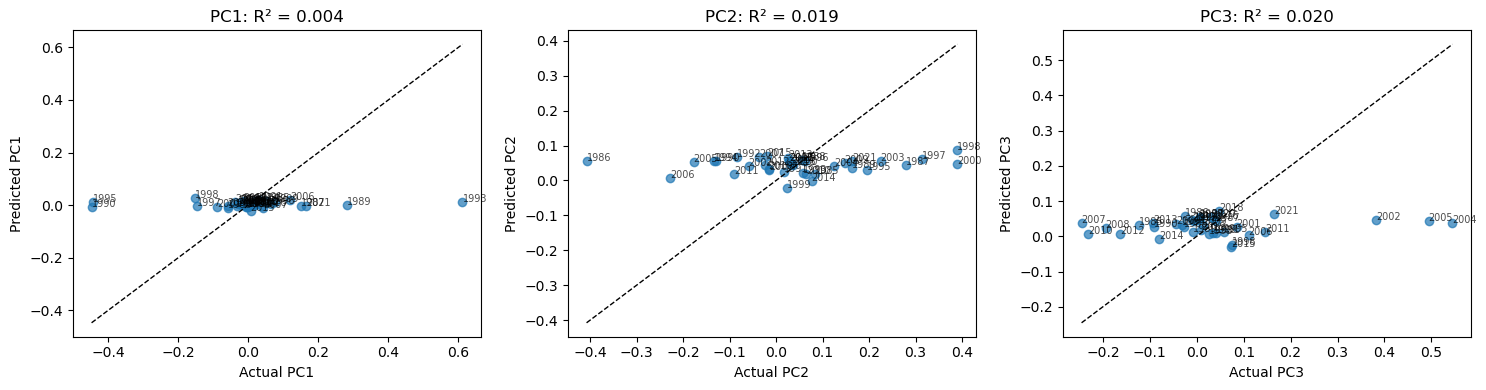


--- Hierarchical Stepwise (cumulative features) ---
PC1: R² = 0.004 (using 1 feature(s))
PC2: R² = 0.041 (using 2 feature(s))
PC3: R² = 0.023 (using 3 feature(s))


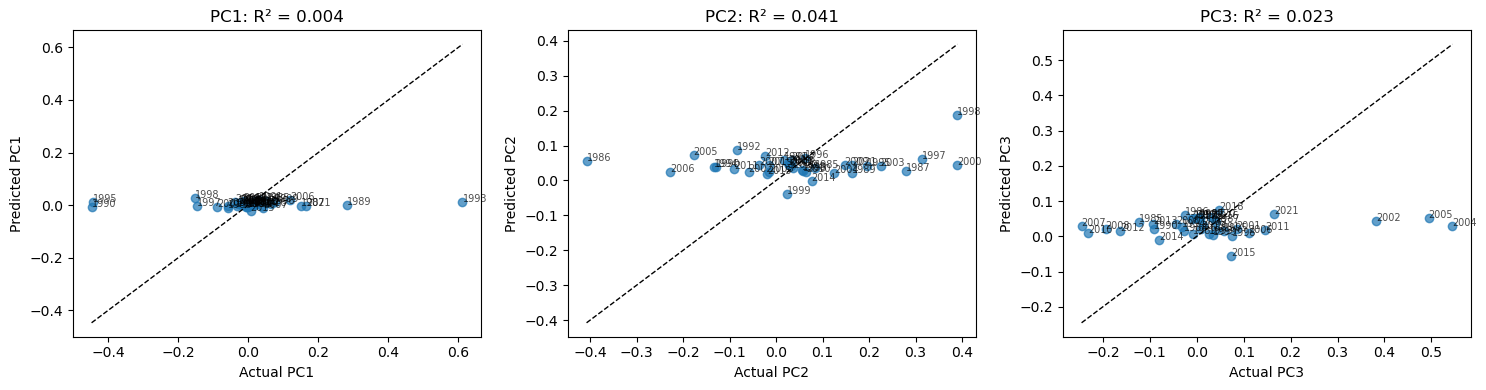


LEAVE-2019-OUT TEST (Hierarchical Stepwise)
PC1: Actual = -0.0209, Predicted = 0.0101, Error = 0.0310, Train R² = 0.004
PC2: Actual = -0.0161, Predicted = 0.0464, Error = 0.0625, Train R² = 0.041
PC3: Actual = 0.0090, Predicted = 0.0218, Error = 0.0128, Train R² = 0.022


In [140]:
# STEPWISE APPROACH
# Logic: PC1 captures overall magnitude, PC2/PC3 capture spatial patterns
# Step 1: Predict PC1 from domain-wide fSCA (total snow coverage)
# Step 2: Predict PC2 from north-south gradient (box1 - box3) or ratio
# Step 3: Predict PC3 from remaining regional contrasts

print("=" * 60)
print("STEPWISE REGRESSION APPROACH")
print("=" * 60)

# Feature design based on physical interpretation:
# - PC1: overall snow magnitude → use domain-wide fSCA
# - PC2: north-south gradient → use box1 - box3 difference
# - PC3: central region anomaly → use box2 deviation from mean of box1 & box3

domain_fsca = mean_sca_area_weighted_april1.values
north_south_diff = april1_box1.values - april1_box3.values
north_south_ratio = april1_box1.values / april1_box3.values
central_deviation = april1_box2.values - (april1_box1.values + april1_box3.values) / 2

# Prepare results storage
stepwise_features = {
    'PC1': domain_fsca.reshape(-1, 1),
    'PC2': north_south_diff.reshape(-1, 1),  # Try difference first
    'PC3': central_deviation.reshape(-1, 1)
}

# Alternative: hierarchical features - each PC gets previous predictors + new
stepwise_features_hierarchical = {
    'PC1': domain_fsca.reshape(-1, 1),
    'PC2': np.column_stack([domain_fsca, north_south_diff]),
    'PC3': np.column_stack([domain_fsca, north_south_diff, central_deviation])
}

print("\n--- Simple Stepwise (each PC → one designed feature) ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (pc_all, pc_name) in enumerate([(pc1_weights, 'PC1'), (pc2_weights, 'PC2'), (pc3_weights, 'PC3')]):
    X_step = stepwise_features[pc_name]
    
    model = LinearRegression()
    model.fit(X_step, pc_all)
    pc_pred = model.predict(X_step)
    r2 = r2_score(pc_all, pc_pred)
    
    print(f"{pc_name}: R² = {r2:.3f}")
    
    # Plot
    axes[i].scatter(pc_all, pc_pred, alpha=0.7)
    axes[i].plot([pc_all.min(), pc_all.max()], [pc_all.min(), pc_all.max()], 'k--', lw=1)
    for j, year in enumerate(years):
        axes[i].annotate(str(year), (pc_all[j], pc_pred[j]), fontsize=7, alpha=0.7)
    axes[i].set_xlabel(f'Actual {pc_name}')
    axes[i].set_ylabel(f'Predicted {pc_name}')
    axes[i].set_title(f'{pc_name}: R² = {r2:.3f}')
    
plt.tight_layout()
plt.show()

print("\n--- Hierarchical Stepwise (cumulative features) ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (pc_all, pc_name) in enumerate([(pc1_weights, 'PC1'), (pc2_weights, 'PC2'), (pc3_weights, 'PC3')]):
    X_step = stepwise_features_hierarchical[pc_name]
    
    model = LinearRegression()
    model.fit(X_step, pc_all)
    pc_pred = model.predict(X_step)
    r2 = r2_score(pc_all, pc_pred)
    
    print(f"{pc_name}: R² = {r2:.3f} (using {X_step.shape[1]} feature(s))")
    
    axes[i].scatter(pc_all, pc_pred, alpha=0.7)
    axes[i].plot([pc_all.min(), pc_all.max()], [pc_all.min(), pc_all.max()], 'k--', lw=1)
    for j, year in enumerate(years):
        axes[i].annotate(str(year), (pc_all[j], pc_pred[j]), fontsize=7, alpha=0.7)
    axes[i].set_xlabel(f'Actual {pc_name}')
    axes[i].set_ylabel(f'Predicted {pc_name}')
    axes[i].set_title(f'{pc_name}: R² = {r2:.3f}')
    
plt.tight_layout()
plt.show()

# Leave-2019-out test with hierarchical approach
print("\n" + "=" * 60)
print("LEAVE-2019-OUT TEST (Hierarchical Stepwise)")
print("=" * 60)

for i, (pc_all, pc_name) in enumerate([(pc1_weights, 'PC1'), (pc2_weights, 'PC2'), (pc3_weights, 'PC3')]):
    X_step = stepwise_features_hierarchical[pc_name]
    
    X_train_step = X_step[train_mask]
    X_test_step = X_step[~train_mask]
    pc_train = pc_all[train_mask]
    pc_test = pc_all[~train_mask][0]
    
    model = LinearRegression()
    model.fit(X_train_step, pc_train)
    pc_pred_2019 = model.predict(X_test_step)[0]
    
    train_r2 = r2_score(pc_train, model.predict(X_train_step))
    
    print(f"{pc_name}: Actual = {pc_test:.4f}, Predicted = {pc_pred_2019:.4f}, Error = {pc_pred_2019 - pc_test:.4f}, Train R² = {train_r2:.3f}")